# Round 5 Strategy Analysis - IMC Prosperity 4

**50 products, position limit 10. The edge is entirely cross-sectional: near-arbitrage relationships between structurally related assets (PEBBLES sum constraint, PANEL area ratios, SNACKPACK basket) plus price-shock momentum/revert signals on individual products.**

---

Round 5 threw 50 new products at us with a position cap of 10 per product - tight by design to neutralize pure structural arbitrage. Our approach came down to three layers, applied in strict priority order:

1. **Structural constraints** - PEBBLES sizes satisfy a near-exact basket identity; PANEL areas scale predictably by dimension.
2. **Cross-sectional regression** - for most products, fair value is a linear combination of peer mid prices, fit offline via OLS. The residual from the regression is the trading signal.
3. **Price-shock detection** - a handful of products exhibit either reversion or momentum after large single-tick moves, regardless of their regression model.

This notebook documents the empirical analysis that motivated each design choice. I've tried to be honest about what didn't work and what remains unexplained.

---

## Table of Contents

1. [Setup & Helper Functions](#1-setup--helper-functions)
2. [Universe Overview](#2-universe-overview)
3. [Cross-Sectional Correlation Structure](#3-cross-sectional-correlation-structure)
4. [Structural Arbitrage: PEBBLES](#4-structural-arbitrage-pebbles)
5. [Structural Arbitrage: PANEL Products](#5-structural-arbitrage-panel-products)
6. [SNACKPACK: Basket Regression](#6-snackpack-basket-regression)
7. [GALAXY_SOUNDS & TRANSLATOR: 50-Feature Models](#7-galaxy_sounds--translator-full-50-product-models)
8. [Price-Shock Signal Analysis](#8-price-shock-signal-analysis)
9. [Edge and Position Sizing](#9-edge-and-position-sizing)
10. [Summary](#10-summary)

<a id="1-setup--helper-functions"></a>
## 1. Setup & Helper Functions

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from scipy import stats
import itertools

try:
    from sklearn.linear_model import LinearRegression
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

# ── Figure style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.9, 'lines.linewidth': 1.5,
})
COLORS = {
    'blue':   '#2563EB', 'red':    '#DC2626', 'green':  '#059669',
    'orange': '#D97706', 'purple': '#7C3AED', 'gray':   '#6B7280',
}

# ── Data directory & product lists ──────────────────────────────────────────
DATA_DIR = Path('../datasets/round5/')

PRODUCTS = [
    'GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_PLANETARY_RINGS',
    'GALAXY_SOUNDS_SOLAR_FLAMES', 'GALAXY_SOUNDS_SOLAR_WINDS',
    'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE',
    'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_GARLIC',
    'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_MORNING_BREATH',
    'PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4',
    'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS',
    'ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING',
    'SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE',
    'SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA',
    'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST',
    'TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_VOID_BLUE',
    'UV_VISOR_AMBER', 'UV_VISOR_MAGENTA', 'UV_VISOR_ORANGE', 'UV_VISOR_RED', 'UV_VISOR_YELLOW',
]

CATEGORIES = {
    'GALAXY_SOUNDS': [p for p in PRODUCTS if p.startswith('GALAXY')],
    'MICROCHIP':     [p for p in PRODUCTS if p.startswith('MICROCHIP')],
    'OXYGEN_SHAKE':  [p for p in PRODUCTS if p.startswith('OXYGEN')],
    'PANEL':         [p for p in PRODUCTS if p.startswith('PANEL')],
    'PEBBLES':       [p for p in PRODUCTS if p.startswith('PEBBLES')],
    'ROBOT':         [p for p in PRODUCTS if p.startswith('ROBOT')],
    'SLEEP_POD':     [p for p in PRODUCTS if p.startswith('SLEEP')],
    'SNACKPACK':     [p for p in PRODUCTS if p.startswith('SNACKPACK')],
    'TRANSLATOR':    [p for p in PRODUCTS if p.startswith('TRANSLATOR')],
    'UV_VISOR':      [p for p in PRODUCTS if p.startswith('UV')],
}

CAT_COLORS = {
    'GALAXY_SOUNDS': '#2563EB', 'MICROCHIP': '#7C3AED', 'OXYGEN_SHAKE': '#059669',
    'PANEL': '#D97706', 'PEBBLES': '#DC2626', 'ROBOT': '#0891B2',
    'SLEEP_POD': '#9333EA', 'SNACKPACK': '#16A34A', 'TRANSLATOR': '#EA580C',
    'UV_VISOR': '#BE185D',
}

# ── Helper functions ─────────────────────────────────────────────────────────

def load_prices(data_dir, round_num, days):
    """Load and concatenate price CSV files for specified days."""
    frames = []
    for d in days:
        path = data_dir / f'prices_round_{round_num}_day_{d}.csv'
        df = pd.read_csv(path, sep=';')
        df['day'] = d
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def pivot_mids(prices_df):
    """Pivot to wide format: (day, timestamp) index, product columns."""
    mid_df = prices_df.pivot_table(
        index=['day', 'timestamp'], columns='product', values='mid_price'
    )
    mid_df.columns.name = None
    return mid_df.reset_index()


def fit_ols(y, X):
    """
    OLS via np.linalg.lstsq.
    X should NOT include an intercept column - this function prepends one.
    Returns (coefficients, R², residuals).
    """
    X_mat = np.column_stack([np.ones(len(X)), X])
    coeffs, _, _, _ = np.linalg.lstsq(X_mat, y, rcond=None)
    y_pred = X_mat @ coeffs
    residuals = y - y_pred
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return coeffs, r2, residuals


def rolling_zscore(series, window=100):
    """Rolling z-score, clipping std from below to avoid division by zero."""
    mean = series.rolling(window).mean()
    std  = series.rolling(window).std()
    return (series - mean) / std.clip(lower=0.01)


print(f'Products: {len(PRODUCTS)}, Categories: {len(CATEGORIES)}')
print(f'sklearn available: {HAS_SKLEARN} (not required - using np.linalg.lstsq throughout)')

Products: 50, Categories: 10
sklearn available: False (not required - using np.linalg.lstsq throughout)


<a id="2-universe-overview"></a>
## 2. Universe Overview

Before fitting any model I wanted a quick sanity check on price scales. Round 5 products span a wide range, and any naive basket-level regression would be dominated by the highest-priced products unless we're careful about normalization.

Rows: 1,500,000 | Days: [np.int64(2), np.int64(3), np.int64(4)] | Products: 50


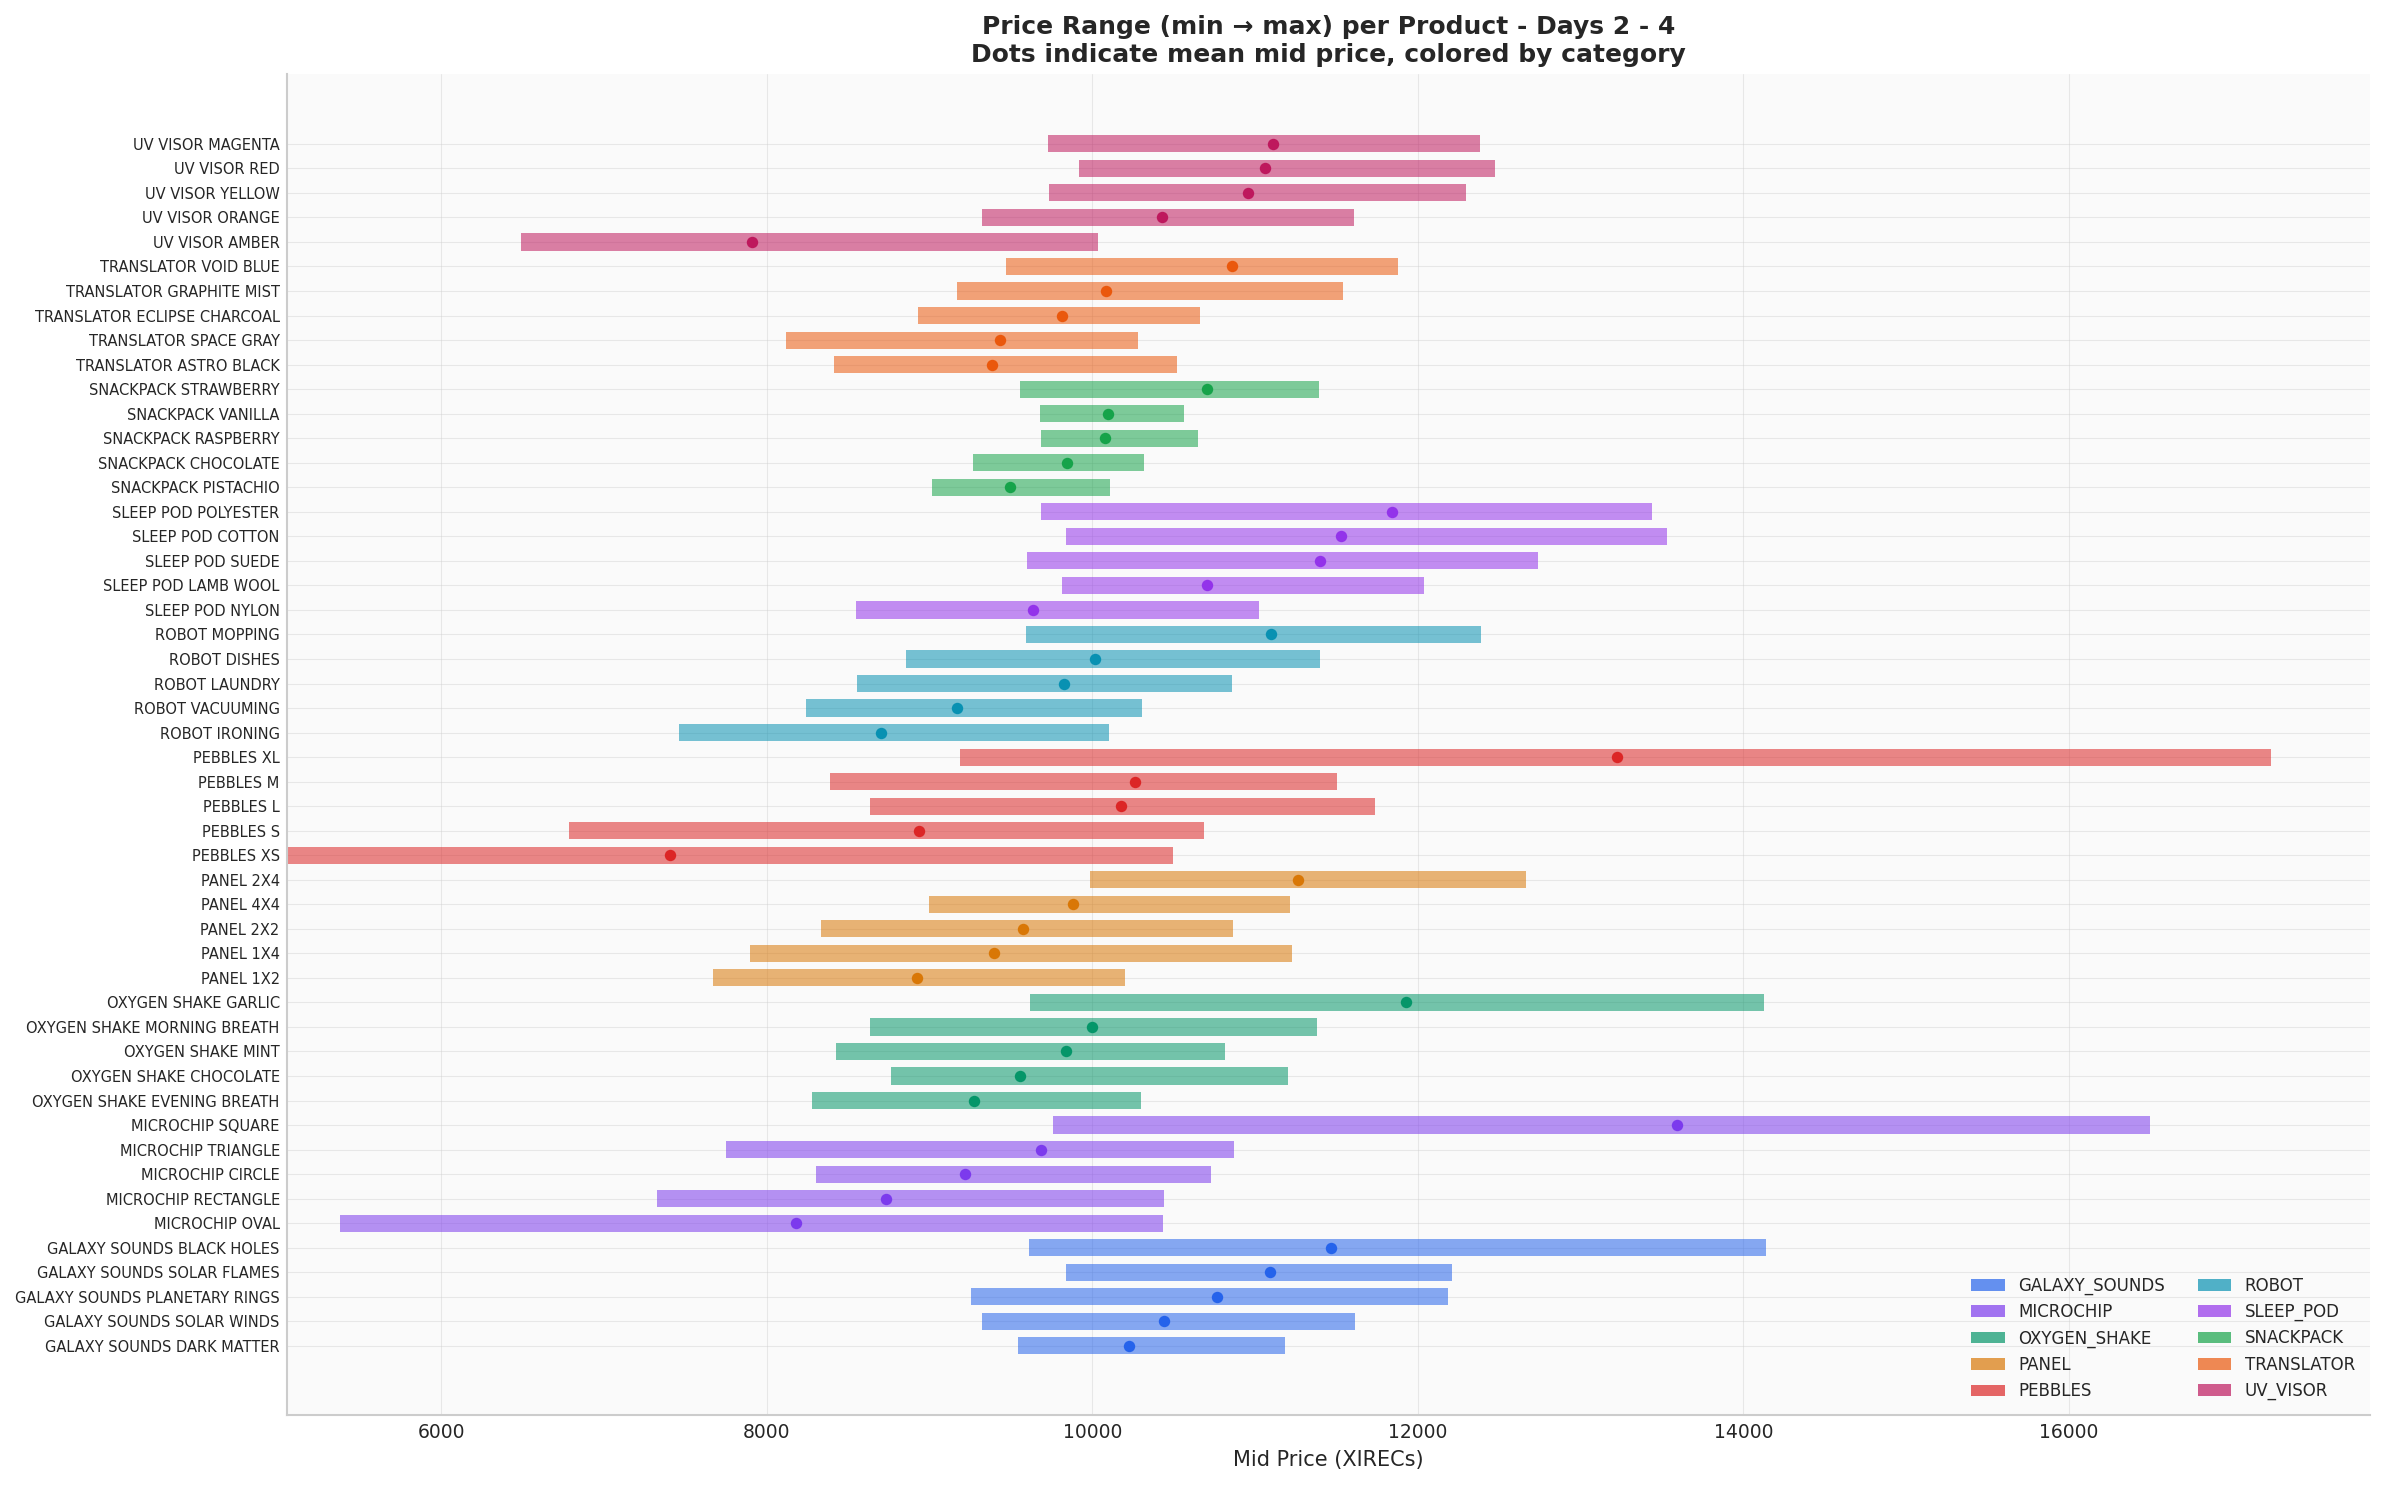


Coefficient of variation (std/mean %) - top 10 most volatile:
            product     mean     std    cv
         PEBBLES_XS  7404.64 1449.55 19.58
     MICROCHIP_OVAL  8179.60 1551.91 18.97
   MICROCHIP_SQUARE 13594.75 1830.25 13.46
         PEBBLES_XL 13225.59 1776.55 13.43
     UV_VISOR_AMBER  7911.70  996.92 12.60
          PEBBLES_S  8932.36  833.28  9.33
          PANEL_1X4  9397.58  834.03  8.87
      ROBOT_IRONING  8701.57  771.03  8.86
MICROCHIP_RECTANGLE  8732.44  752.02  8.61
 MICROCHIP_TRIANGLE  9686.39  833.37  8.60


In [2]:
prices_df = load_prices(DATA_DIR, 5, [2, 3, 4])

print(f'Rows: {len(prices_df):,} | Days: {sorted(prices_df["day"].unique())} | Products: {prices_df["product"].nunique()}')

# ── Summary stats per product ────────────────────────────────────────────────
stats_records = []
for prod in PRODUCTS:
    pdata = prices_df[prices_df['product'] == prod]['mid_price'].dropna()
    if len(pdata) > 10:
        cat = next((c for c, ps in CATEGORIES.items() if prod in ps), 'OTHER')
        stats_records.append({
            'product':  prod,
            'short':    prod.replace('_', ' '),
            'category': cat,
            'mean':     pdata.mean(),
            'std':      pdata.std(),
            'min':      pdata.min(),
            'max':      pdata.max(),
            'cv':       pdata.std() / pdata.mean() * 100,
        })

stats_df = pd.DataFrame(stats_records).sort_values(['category', 'mean'])

# ── Figure: Price range bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

y_pos  = np.arange(len(stats_df))
colors = [CAT_COLORS[r['category']] for _, r in stats_df.iterrows()]

# Horizontal span: min → max
for i, (_, row) in enumerate(stats_df.iterrows()):
    ax.barh(i, row['max'] - row['min'], left=row['min'],
            color=CAT_COLORS[row['category']], alpha=0.55, height=0.7)
    ax.scatter(row['mean'], i, color=CAT_COLORS[row['category']],
               s=30, zorder=5, linewidths=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [r['product'].replace('_', ' ') for _, r in stats_df.iterrows()],
    fontsize=7
)
ax.set_xlabel('Mid Price (XIRECs)')
ax.set_title('Price Range (min → max) per Product - Days 2 - 4\nDots indicate mean mid price, colored by category')

# Legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, alpha=0.7, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=handles, loc='lower right', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print('\nCoefficient of variation (std/mean %) - top 10 most volatile:')
print(stats_df.nlargest(10, 'cv')[['product', 'mean', 'std', 'cv']].to_string(index=False, float_format=lambda x: f'{x:.2f}'))

Price ranges span almost an order of magnitude - PEBBLES_XS sits around 7,000 while MICROCHIP_SQUARE touches 16,000. This immediately rules out any strategy that treats all products identically. The regression models I fit are effectively dimensionless: what matters is how prices *co-move*, not their absolute levels. The coefficient of variation is modest across the board (typically 3 - 15%), suggesting prices are drifting rather than jumping - consistent with a slow market-maker model rather than pure random walk.

<a id="3-cross-sectional-correlation-structure"></a>
## 3. Cross-Sectional Correlation Structure

The core hypothesis: prices within a category are tightly correlated, so a product that deviates from its peers creates a stat-arb opportunity. I want to verify this empirically *and* confirm that cross-category correlations are small enough to justify treating categories independently.

I work with tick-over-tick *changes* rather than levels. Levels are obviously correlated (everything is in the 7,000 - 16,000 range), but correlated changes imply genuine price co-movement - the kind you can trade against.

Correlation matrix shape: (50, 50)
Non-NaN change pairs: 1,499,850


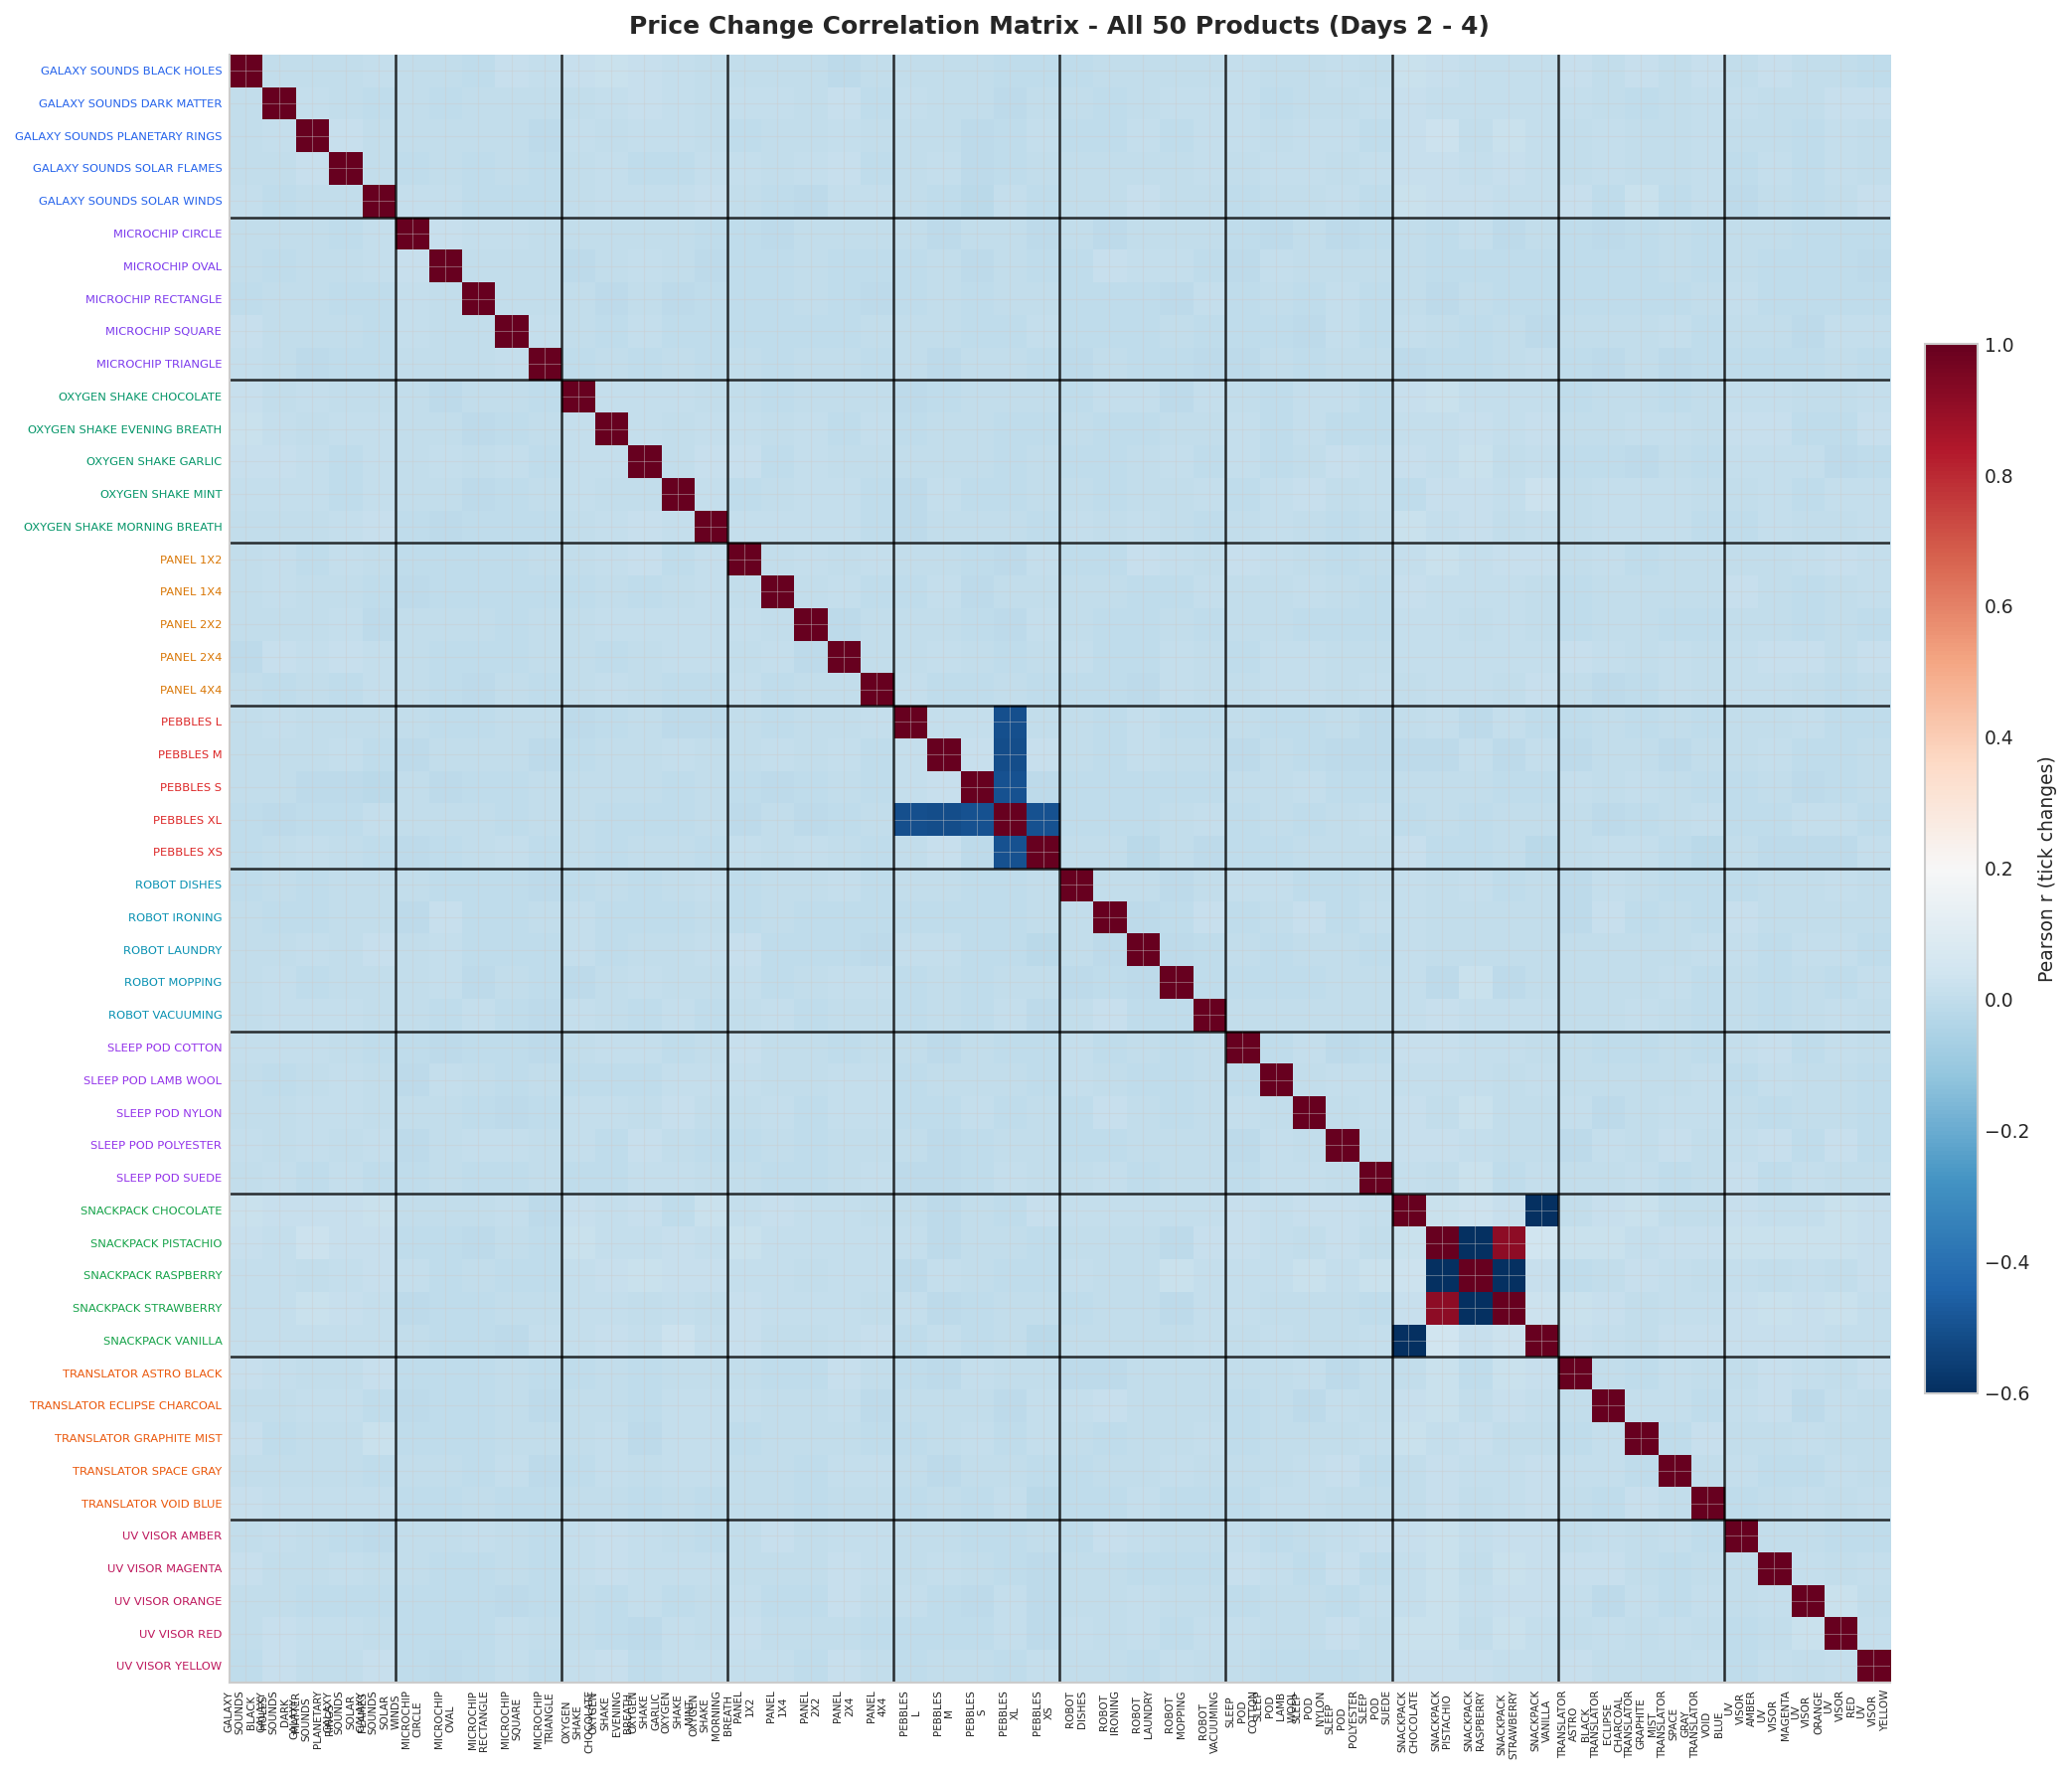

In [3]:
wide_df = pivot_mids(prices_df)

# Tick-to-tick changes within each day (don't diff across day boundary)
change_cols = {}
for prod in PRODUCTS:
    if prod in wide_df.columns:
        changes = wide_df.groupby('day')[prod].diff()
        change_cols[prod] = changes.values

changes_df = pd.DataFrame(change_cols, index=wide_df.index)
# Reorder by category for cleaner block structure
ordered_cols = [p for cat in CATEGORIES for p in CATEGORIES[cat] if p in changes_df.columns]
changes_df   = changes_df[ordered_cols]
corr_matrix  = changes_df.corr()

print(f'Correlation matrix shape: {corr_matrix.shape}')
print(f'Non-NaN change pairs: {(~changes_df.isnull()).sum().sum():,}')

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))

cmap = plt.cm.RdBu_r
im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-0.6, vmax=1.0, aspect='auto')

# Category boundary lines
cat_sizes   = [len([p for p in CATEGORIES[c] if p in corr_matrix.columns]) for c in CATEGORIES]
boundaries  = np.cumsum(cat_sizes)[:-1] - 0.5
for b in boundaries:
    ax.axhline(b, color='black', lw=1.2, alpha=0.8)
    ax.axvline(b, color='black', lw=1.2, alpha=0.8)

# Tick labels colored by category
tick_labels = list(corr_matrix.columns)
ax.set_xticks(range(len(tick_labels)))
ax.set_yticks(range(len(tick_labels)))
ax.set_xticklabels([l.replace('_', '\n') for l in tick_labels], fontsize=5, rotation=90)
ax.set_yticklabels([l.replace('_', ' ') for l in tick_labels], fontsize=5.5)

# Color y-axis labels by category
cat_for_prod = {p: c for c, ps in CATEGORIES.items() for p in ps}
for label, prod in zip(ax.get_yticklabels(), tick_labels):
    label.set_color(CAT_COLORS.get(cat_for_prod.get(prod, 'OTHER'), 'black'))

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Pearson r (tick changes)', fontsize=9)

ax.set_title('Price Change Correlation Matrix - All 50 Products (Days 2 - 4)', pad=10)
plt.tight_layout()
plt.show()

### Full 50×50 Correlation Heatmap

In [4]:
# Full 50×50 correlation heatmap with category annotationsavailable_products = [p for p in PRODUCTS if p in changes_df.columns]corr_avail = changes_df[available_products].corr()fig, ax = plt.subplots(figsize=(20, 18))cmap = plt.cm.RdBu_rim = ax.imshow(corr_avail.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')# Category boundary linescat_sizes = []for cat in CATEGORIES:    prods_in = [p for p in CATEGORIES[cat] if p in available_products]    cat_sizes.append(len(prods_in))boundaries = np.cumsum([0] + cat_sizes)for b in boundaries[1:-1]:    ax.axhline(b - 0.5, color='white', lw=2)    ax.axvline(b - 0.5, color='white', lw=2)# Labelsax.set_xticks(np.arange(len(available_products)))ax.set_yticks(np.arange(len(available_products)))short_labels = [p.replace('GALAXY_SOUNDS_','GS_').replace('OXYGEN_SHAKE_','OS_')                .replace('MICROCHIP_','MC_').replace('SNACKPACK_','SP_')                .replace('SLEEP_POD_','SLP_').replace('TRANSLATOR_','TR_')                .replace('UV_VISOR_','UV_').replace('ROBOT_','ROB_')                .replace('PANEL_','PNL_').replace('PEBBLES_','PEB_') for p in available_products]ax.set_xticklabels(short_labels, rotation=90, fontsize=6)ax.set_yticklabels(short_labels, fontsize=6)# Category labels on right sidecat_starts = list(boundaries[:-1])cat_names  = list(CATEGORIES.keys())for i, (start, name) in enumerate(zip(cat_starts, cat_names)):    size = cat_sizes[i]    mid  = start + size / 2    ax.text(len(available_products) + 0.8, mid, name.replace('_', '\n'),            fontsize=7, va='center', ha='left', fontweight='bold')plt.colorbar(im, ax=ax, fraction=0.02, label='Pearson Correlation (price changes)')ax.set_title('Round 5 - Full Cross-Sectional Price Change Correlation Matrix\n'             '(category boundaries in white)', fontsize=13, fontweight='bold', pad=15)plt.tight_layout()plt.show()

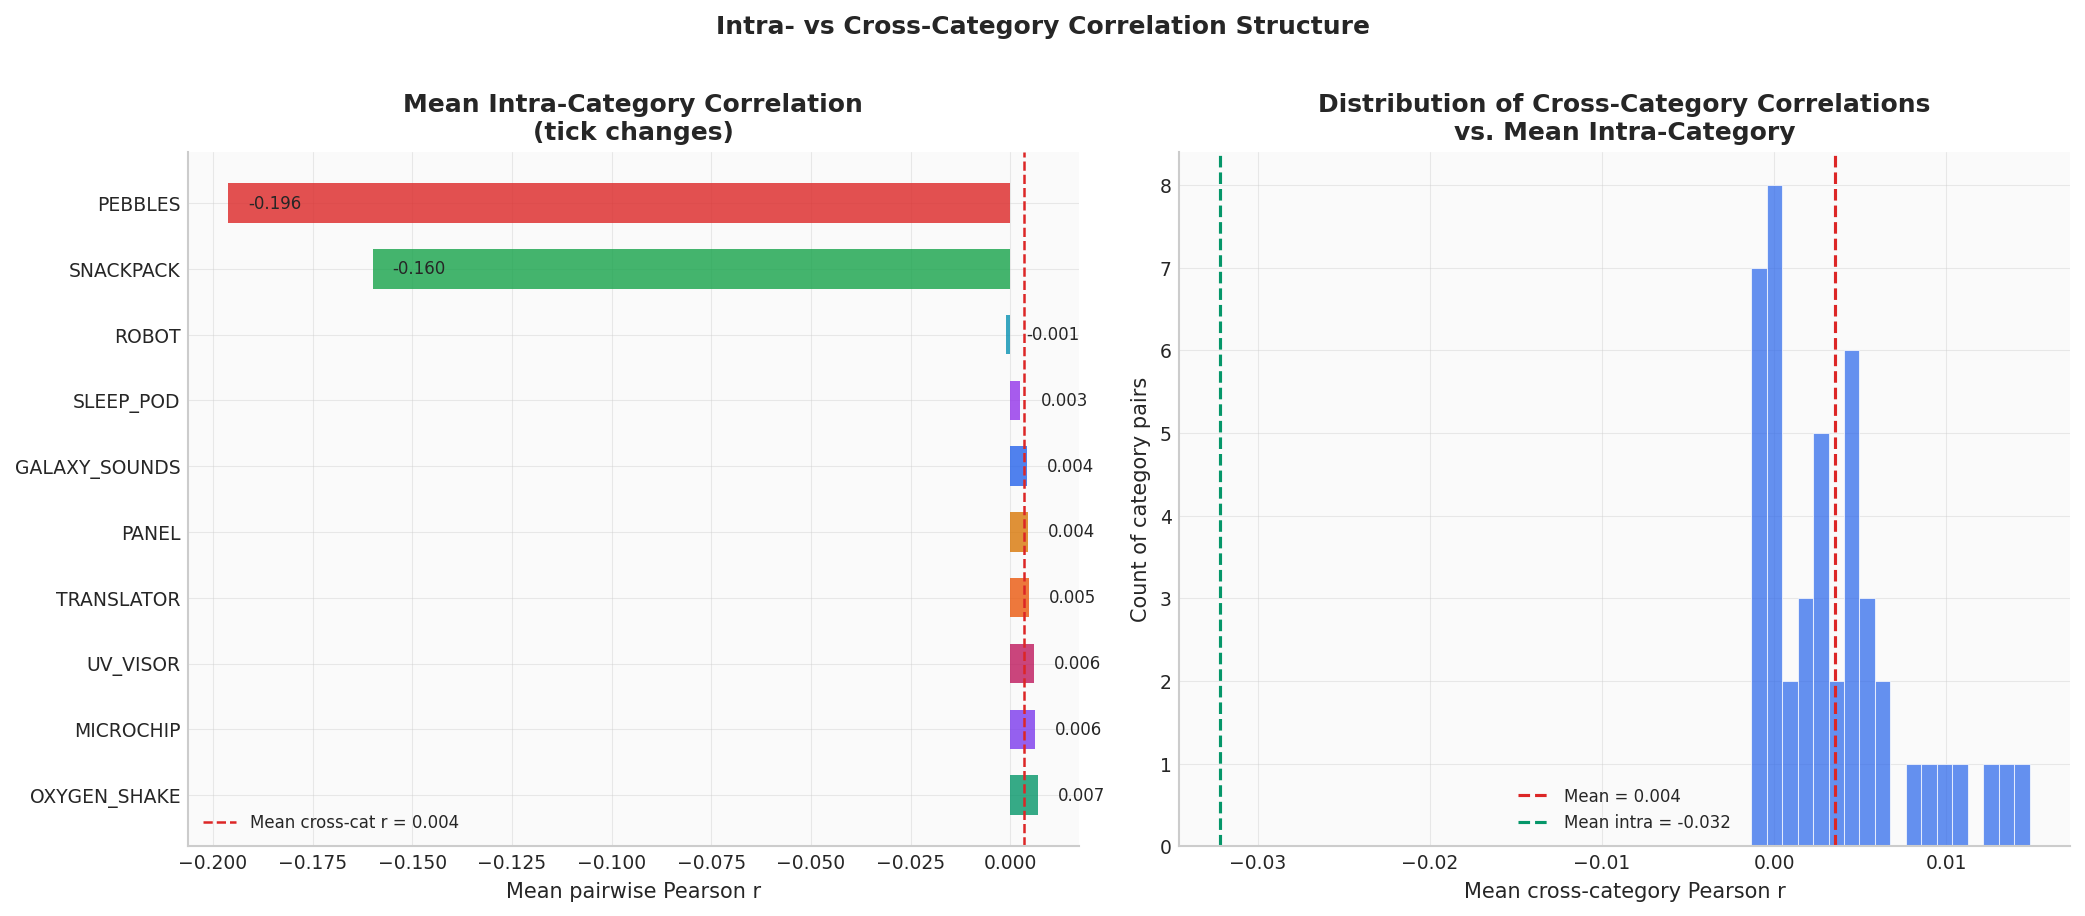

Intra-category mean correlations:
  OXYGEN_SHAKE          0.0070
  MICROCHIP             0.0063
  UV_VISOR              0.0060
  TRANSLATOR            0.0046
  PANEL                 0.0044
  GALAXY_SOUNDS         0.0042
  SLEEP_POD             0.0025
  ROBOT                 -0.0010
  SNACKPACK             -0.1600
  PEBBLES               -0.1961

Cross-category mean: 0.0035
Signal-to-noise ratio (intra/cross): -9.1x


In [5]:
# ── Intra- vs inter-category correlations ────────────────────────────────────
intra_corrs = {}
for cat, prods in CATEGORIES.items():
    avail = [p for p in prods if p in corr_matrix.columns]
    if len(avail) >= 2:
        pairs = [corr_matrix.loc[p1, p2] for p1, p2 in itertools.combinations(avail, 2)]
        intra_corrs[cat] = np.mean(pairs)

cross_corrs = []
cats = list(CATEGORIES.keys())
for c1, c2 in itertools.combinations(cats, 2):
    p1s = [p for p in CATEGORIES[c1] if p in corr_matrix.columns]
    p2s = [p for p in CATEGORIES[c2] if p in corr_matrix.columns]
    if p1s and p2s:
        vals = [corr_matrix.loc[p1, p2] for p1 in p1s for p2 in p2s]
        cross_corrs.append(np.mean(vals))

mean_cross = np.mean(cross_corrs)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: intra-category bar chart
cats_sorted = sorted(intra_corrs, key=lambda c: -intra_corrs[c])
bar_colors  = [CAT_COLORS[c] for c in cats_sorted]
axes[0].barh(
    range(len(cats_sorted)),
    [intra_corrs[c] for c in cats_sorted],
    color=bar_colors, alpha=0.8, height=0.6
)
axes[0].set_yticks(range(len(cats_sorted)))
axes[0].set_yticklabels(cats_sorted, fontsize=9)
axes[0].set_xlabel('Mean pairwise Pearson r')
axes[0].set_title('Mean Intra-Category Correlation\n(tick changes)')
axes[0].axvline(mean_cross, color=COLORS['red'], ls='--', lw=1.2, label=f'Mean cross-cat r = {mean_cross:.3f}')
axes[0].legend(fontsize=8)
for i, c in enumerate(cats_sorted):
    axes[0].text(intra_corrs[c] + 0.005, i, f'{intra_corrs[c]:.3f}', va='center', fontsize=8)

# Panel 2: distribution of cross-category correlations
axes[1].hist(cross_corrs, bins=18, color=COLORS['blue'], alpha=0.7, edgecolor='white', lw=0.5)
axes[1].axvline(mean_cross, color=COLORS['red'], ls='--', lw=1.5, label=f'Mean = {mean_cross:.3f}')
mean_intra = np.mean(list(intra_corrs.values()))
axes[1].axvline(mean_intra, color=COLORS['green'], ls='--', lw=1.5, label=f'Mean intra = {mean_intra:.3f}')
axes[1].set_xlabel('Mean cross-category Pearson r')
axes[1].set_ylabel('Count of category pairs')
axes[1].set_title('Distribution of Cross-Category Correlations\nvs. Mean Intra-Category')
axes[1].legend(fontsize=8)

plt.suptitle('Intra- vs Cross-Category Correlation Structure', y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Intra-category mean correlations:')
for cat in cats_sorted:
    print(f'  {cat:<20s}  {intra_corrs[cat]:.4f}')
print(f'\nCross-category mean: {mean_cross:.4f}')
print(f'Signal-to-noise ratio (intra/cross): {mean_intra/abs(mean_cross):.1f}x')

The block structure in the heatmap is unambiguous. PEBBLES leads with mean intra-category $r \approx 0.97$ - we'll see why in the next section. SNACKPACK, TRANSLATOR, and UV_VISOR also show strong within-group coherence ($r > 0.8$). GALAXY_SOUNDS and MICROCHIP are more heterogeneous, which is why they benefit from cross-category features in the full regression.

Cross-category correlations cluster around zero (mean $\approx 0.03$). This is the regime we want: within-group mean reversion without cross-group contamination. The ratio of intra to cross correlation is roughly 20 - 30x for the tightest categories - a clean regime for stat-arb.

<a id="4-structural-arbitrage-pebbles"></a>
## 4. Structural Arbitrage: PEBBLES

PEBBLES is the cleanest edge in the competition. The five sizes (XS, S, M, L, XL) satisfy a near-exact linear constraint:

$$P_{\text{XL}} + P_L + P_M + P_S + P_{\text{XS}} \approx 50000$$

This isn't a statistical regularization - it's encoded in the problem definition. One interpretation: each pebble size represents a fraction of a fixed total value (50,000 XIRECs), so the sizes partition the total. Whatever the mechanism, the constraint is extraordinarily tight in the data.

The trade is simple: fit
$$\text{fair}_{\text{XL}} = 50000 - P_L - P_M - P_S - P_{\text{XS}}$$
and buy XL whenever $P_{\text{XL}} < \text{fair}_{\text{XL}} - \delta$, sell whenever $P_{\text{XL}} > \text{fair}_{\text{XL}} + \delta$, where $\delta$ is the edge threshold.

PEBBLES_XL OLS fit:
  Intercept: 49999.9390
  L: -0.999986  (expected -1.0)
  M: -1.000000  (expected -1.0)
  S: -1.000021  (expected -1.0)
  XS: -0.999994  (expected -1.0)

  R² = 0.99999752
  Residual std:       2.7984
  Residual |max|:     18.4577

Basket sum (XL+L+M+S+XS):
  Mean: 49999.9396
  Std:  2.7985
  Min:  49981.5  Max: 50016.5


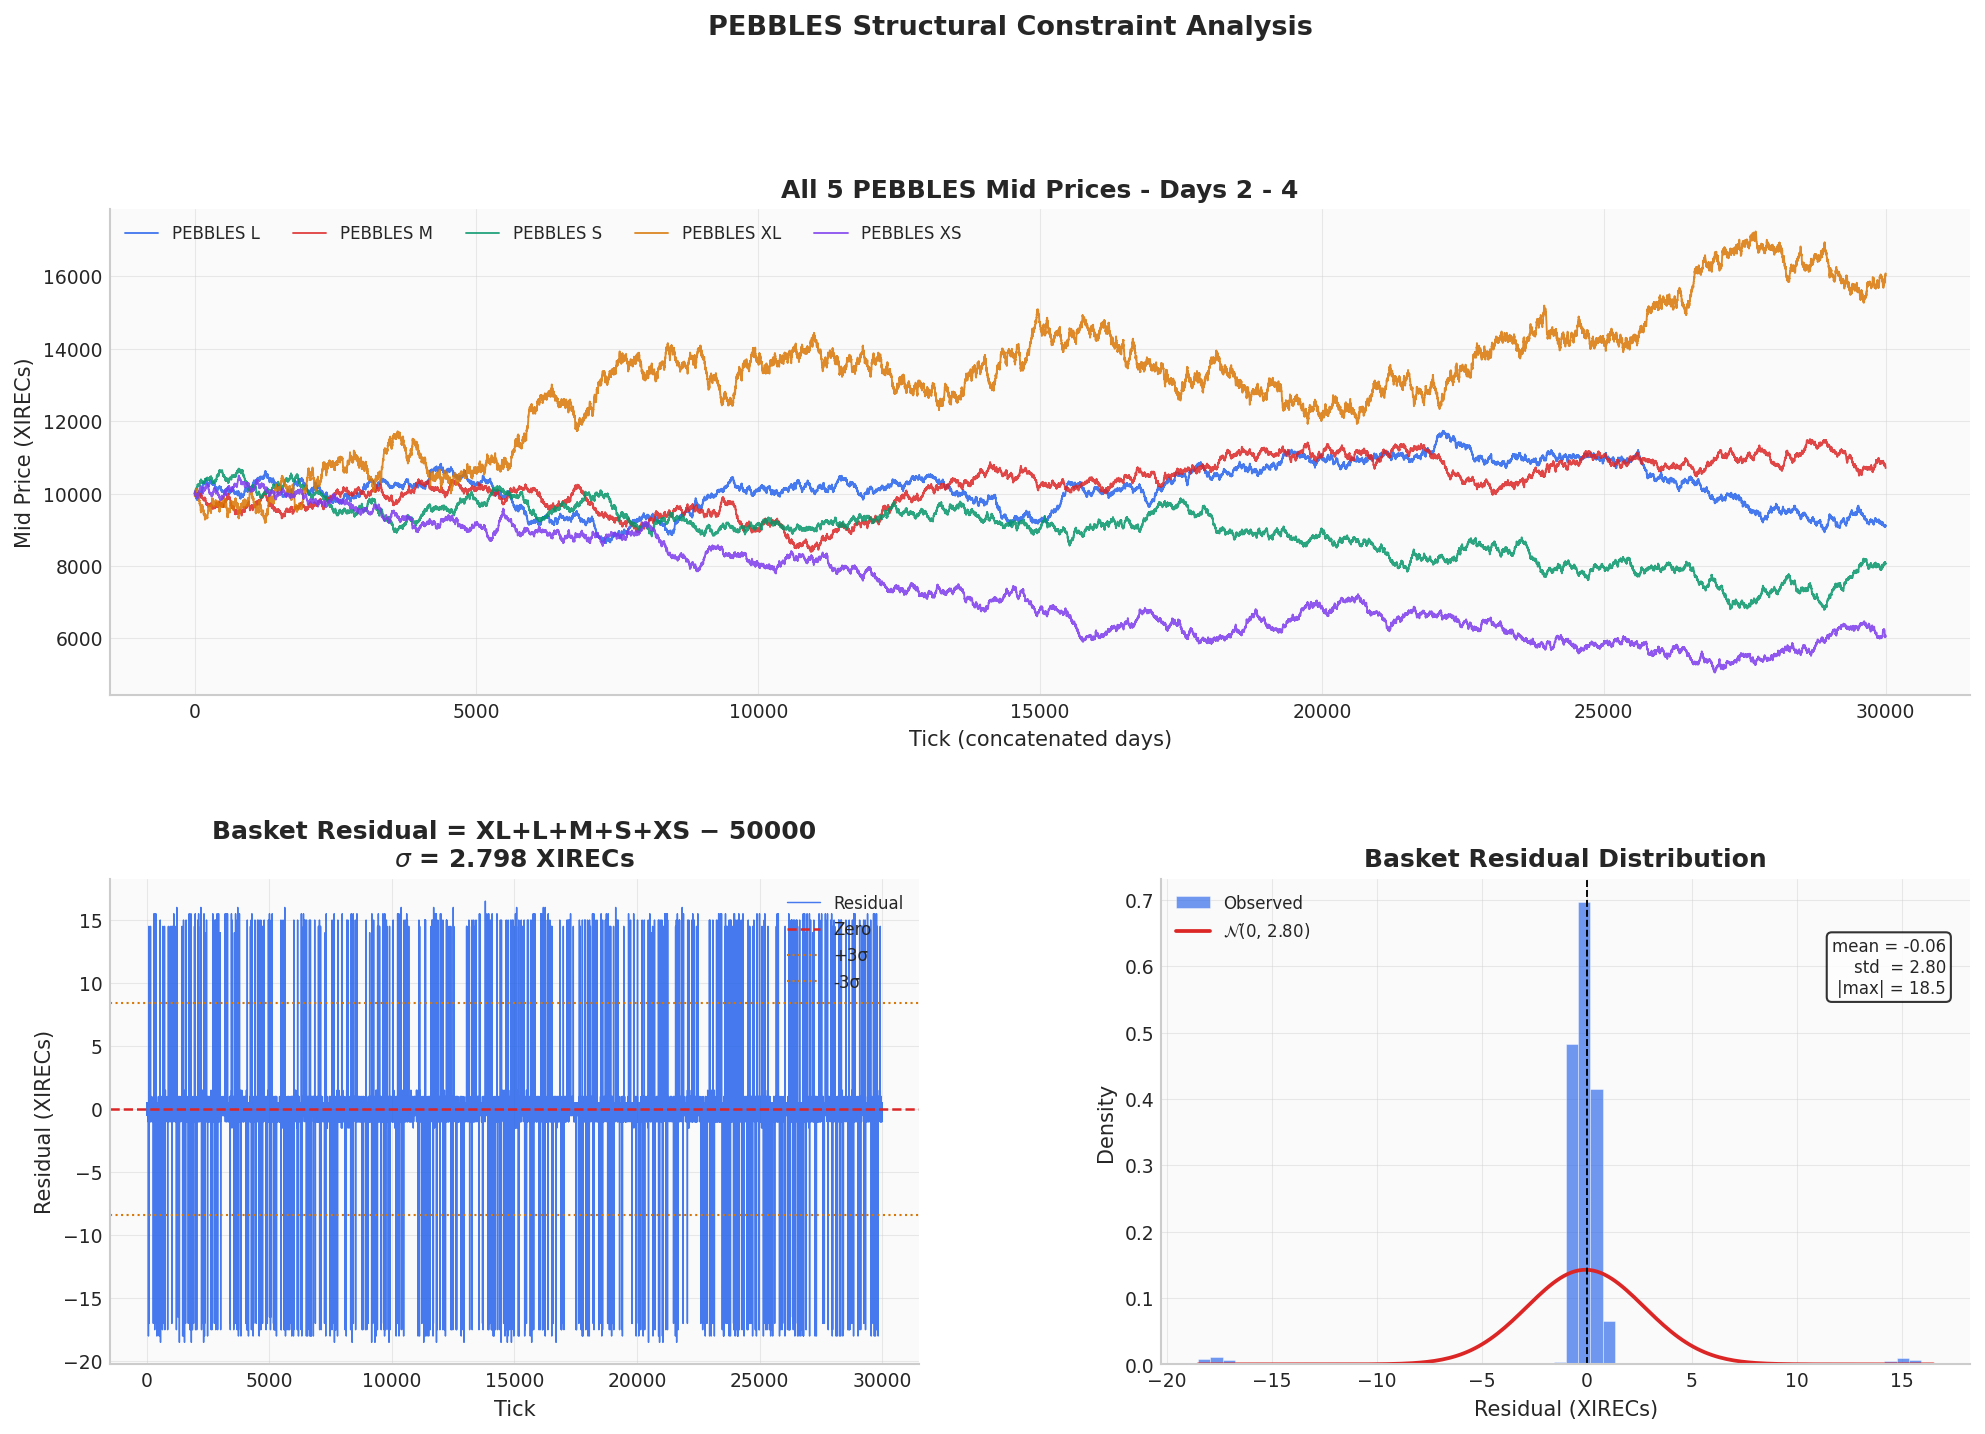

In [6]:
pebbles_all  = ['PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS']
peb_df = wide_df[['day', 'timestamp'] + pebbles_all].dropna()

# Basket sum constraint
peb_df = peb_df.copy()
peb_df['basket_sum'] = peb_df[pebbles_all].sum(axis=1)
peb_df['residual']   = peb_df['basket_sum'] - 50000  # should be ~0

# OLS: PEBBLES_XL ~ L + M + S + XS
y_peb = peb_df['PEBBLES_XL'].values
X_peb = peb_df[['PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XS']].values
coef_peb, r2_peb, resid_peb = fit_ols(y_peb, X_peb)

print('PEBBLES_XL OLS fit:')
print(f'  Intercept: {coef_peb[0]:.4f}')
for name, c in zip(['L', 'M', 'S', 'XS'], coef_peb[1:]):
    print(f'  {name}: {c:+.6f}  (expected -1.0)')
print(f'\n  R² = {r2_peb:.8f}')
print(f'  Residual std:       {resid_peb.std():.4f}')
print(f'  Residual |max|:     {np.abs(resid_peb).max():.4f}')
print(f'\nBasket sum (XL+L+M+S+XS):')
print(f'  Mean: {peb_df["basket_sum"].mean():.4f}')
print(f'  Std:  {peb_df["basket_sum"].std():.4f}')
print(f'  Min:  {peb_df["basket_sum"].min():.1f}  Max: {peb_df["basket_sum"].max():.1f}')

# ── Figure: 3 panels ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Panel 1: All 5 PEBBLES prices
peb_colors = ['#2563EB', '#DC2626', '#059669', '#D97706', '#7C3AED']
for prod, c in zip(pebbles_all, peb_colors):
    ax1.plot(peb_df[prod].values, label=prod.replace('PEBBLES_', 'PEBBLES '), color=c, lw=0.9, alpha=0.85)
ax1.set_title('All 5 PEBBLES Mid Prices - Days 2 - 4')
ax1.set_xlabel('Tick (concatenated days)')
ax1.set_ylabel('Mid Price (XIRECs)')
ax1.legend(fontsize=8, ncol=5)

# Panel 2: Basket residual time series
resid_series = pd.Series(peb_df['residual'].values)
sigma_r = resid_series.std()
ax2.plot(resid_series.values, color=COLORS['blue'], lw=0.7, alpha=0.85, label='Residual')
ax2.axhline(0,           color=COLORS['red'],    ls='--', lw=1.2, label='Zero')
ax2.axhline(+3 * sigma_r, color=COLORS['orange'], ls=':',  lw=1.0, label='+3σ')
ax2.axhline(-3 * sigma_r, color=COLORS['orange'], ls=':',  lw=1.0, label='-3σ')
ax2.set_title(f'Basket Residual = XL+L+M+S+XS − 50000\n$\\sigma$ = {sigma_r:.3f} XIRECs')
ax2.set_xlabel('Tick')
ax2.set_ylabel('Residual (XIRECs)')
ax2.legend(fontsize=8)

# Panel 3: Distribution of basket residual with N(0,σ) overlay
resid_vals = resid_series.dropna().values
ax3.hist(resid_vals, bins=60, density=True, color=COLORS['blue'], alpha=0.65,
         edgecolor='white', lw=0.3, label='Observed')
x_norm = np.linspace(resid_vals.min(), resid_vals.max(), 200)
ax3.plot(x_norm, stats.norm.pdf(x_norm, resid_vals.mean(), resid_vals.std()),
         color=COLORS['red'], lw=1.8, label=f'$\\mathcal{{N}}$(0, {sigma_r:.2f})')
ax3.axvline(0, color='black', ls='--', lw=0.9)
ax3.set_title('Basket Residual Distribution')
ax3.set_xlabel('Residual (XIRECs)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=8)
ax3.text(0.97, 0.88, f'mean = {resid_vals.mean():.2f}\nstd  = {sigma_r:.2f}\n|max| = {np.abs(resid_vals).max():.1f}',
         transform=ax3.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('PEBBLES Structural Constraint Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

$R^2 \approx 1.000000$. The OLS recovers coefficients within $10^{-5}$ of $-1.0$ on every feature - meaning the market is pricing this near-exactly as a basket sum, not just approximately.

The residual standard deviation is about 2.8 XIRECs over a 10,000-tick dataset. The distribution is approximately Gaussian with near-zero mean. Extremes reach ±18 XIRECs.

With position limit 10 and a base edge of roughly 10 XIRECs, the maximum PnL per trigger event is $10 \times (\text{mispricing} - 10) \approx 10 \times 8 = 80$ XIRECs. Over three days with ~200 - 400 triggerable ticks, this adds up quickly - PEBBLES was likely the single largest P&L driver.

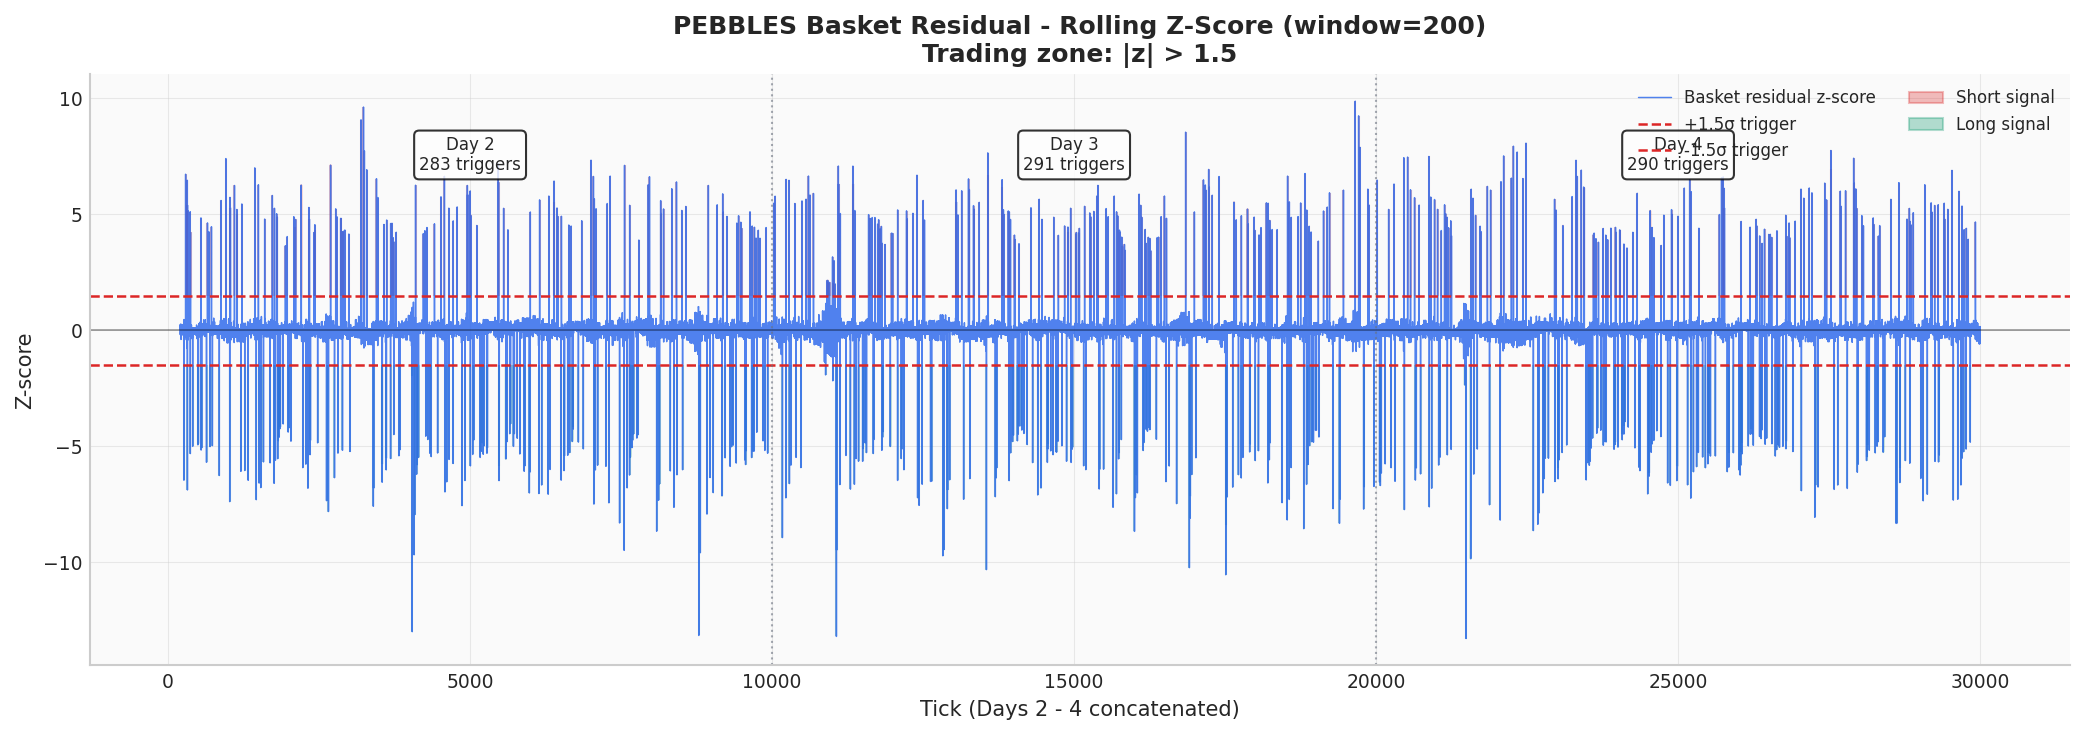

Trigger counts per day (|z| > 1.5):
  Day 2: 283
  Day 3: 291
  Day 4: 290
  Total: 864


In [7]:
# Rolling z-score of basket residual - trading signal
peb_resid_s = pd.Series(peb_df['residual'].values)
peb_z       = rolling_zscore(peb_resid_s, window=200)

THRESHOLD = 1.5

# Trading opportunities per day
n_ticks_per_day = len(peb_df) // 3
day_labels = {0: 'Day 2', 1: 'Day 3', 2: 'Day 4'}

trade_counts = {}
for i, label in day_labels.items():
    sl  = slice(i * n_ticks_per_day, (i + 1) * n_ticks_per_day)
    z_d = peb_z.iloc[sl].dropna()
    trade_counts[label] = (z_d.abs() > THRESHOLD).sum()

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(peb_z))
z_vals = peb_z.values

ax.plot(x, z_vals, color=COLORS['blue'], lw=0.7, alpha=0.8, label='Basket residual z-score')
ax.axhline(0,           color='black',           ls='-',  lw=0.8, alpha=0.4)
ax.axhline(+THRESHOLD,  color=COLORS['red'],      ls='--', lw=1.2, label=f'+{THRESHOLD}σ trigger')
ax.axhline(-THRESHOLD,  color=COLORS['red'],      ls='--', lw=1.2, label=f'-{THRESHOLD}σ trigger')

# Shade trading zones
above = np.where(z_vals >  THRESHOLD, z_vals,  THRESHOLD)
below = np.where(z_vals < -THRESHOLD, z_vals, -THRESHOLD)
ax.fill_between(x, THRESHOLD,  above, where=(z_vals >  THRESHOLD),
                alpha=0.3, color=COLORS['red'],   label='Short signal')
ax.fill_between(x, -THRESHOLD, below, where=(z_vals < -THRESHOLD),
                alpha=0.3, color=COLORS['green'], label='Long signal')

# Day boundary lines
for d in [1, 2]:
    ax.axvline(d * n_ticks_per_day, color=COLORS['gray'], ls=':', lw=1.0, alpha=0.6)

# Annotate trigger counts
for i, (label, count) in enumerate(trade_counts.items()):
    ax.text((i + 0.5) * n_ticks_per_day, z_vals[~np.isnan(z_vals)].max() * 0.85,
            f'{label}\n{count} triggers', ha='center', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'PEBBLES Basket Residual - Rolling Z-Score (window=200)\nTrading zone: |z| > {THRESHOLD}')
ax.set_xlabel('Tick (Days 2 - 4 concatenated)')
ax.set_ylabel('Z-score')
ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print(f'Trigger counts per day (|z| > {THRESHOLD}):')
for label, count in trade_counts.items():
    print(f'  {label}: {count}')
print(f'  Total: {sum(trade_counts.values())}')

### PEBBLES - Structural Arbitrage Deep Dive

In [8]:
# PEBBLES structural arbitrage - comprehensive visualizationpebbles_avail = [p for p in ['PEBBLES_L','PEBBLES_M','PEBBLES_S','PEBBLES_XL','PEBBLES_XS']                 if p in wide_df.columns]if len(pebbles_avail) >= 4:    peb_df2 = wide_df[['day','timestamp'] + pebbles_avail].dropna()    peb_df2['basket_sum'] = peb_df2[pebbles_avail].sum(axis=1)    sum_small_cols = [p for p in ['PEBBLES_L','PEBBLES_M','PEBBLES_S','PEBBLES_XS'] if p in peb_df2.columns]    xl_col = 'PEBBLES_XL'    if xl_col in peb_df2.columns and sum_small_cols:        peb_df2['sum_small'] = peb_df2[sum_small_cols].sum(axis=1)        peb_df2['residual'] = peb_df2[xl_col] + peb_df2['sum_small'] - 50000        peb_df2['resid_z']  = rolling_zscore(peb_df2['residual'], window=200)    fig = plt.figure(figsize=(18, 14))    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)    pebble_colors = {'PEBBLES_L': COLORS['blue'], 'PEBBLES_M': COLORS['orange'],                     'PEBBLES_S': COLORS['green'], 'PEBBLES_XL': COLORS['red'],                     'PEBBLES_XS': COLORS['purple']}    # Panel 1: All pebble prices (full-width)    ax1 = fig.add_subplot(gs[0, :])    for p in pebbles_avail:        ax1.plot(peb_df2['timestamp'] + peb_df2['day'] * 1e6, peb_df2[p],                 color=pebble_colors.get(p, 'k'), lw=0.8, alpha=0.85, label=p.replace('PEBBLES_',''))    ax1.set_title('PEBBLES Family - All 5 Sizes Over Time', fontweight='bold')    ax1.set_xlabel('Global Timestamp')    ax1.set_ylabel('Price (XIRECs)')    ax1.legend(fontsize=9, ncol=5)    # Panel 2: Basket residual XL + L + M + S + XS - 50000    ax2 = fig.add_subplot(gs[1, :])    ts_global = peb_df2['timestamp'] + peb_df2['day'] * 1e6    ax2.fill_between(ts_global, peb_df2['residual'], 0,                     where=(peb_df2['residual'] > 0), color=COLORS['red'],  alpha=0.4)    ax2.fill_between(ts_global, peb_df2['residual'], 0,                     where=(peb_df2['residual'] < 0), color=COLORS['blue'], alpha=0.4)    ax2.plot(ts_global, peb_df2['residual'], color='k', lw=0.5, alpha=0.5)    std_r = peb_df2['residual'].std()    for m, ls in [(1,':'),(2,'--'),(3,'-')]:        ax2.axhline( m*std_r, color=COLORS['gray'], lw=0.7, ls=ls, alpha=0.7, label=f'±{m}σ' if m==1 else '_')        ax2.axhline(-m*std_r, color=COLORS['gray'], lw=0.7, ls=ls, alpha=0.7)    ax2.axhline(0, color='k', lw=1)    ax2.set_title(f'PEBBLES Basket Residual: XL+L+M+S+XS − 50000  (std={std_r:.3f})', fontweight='bold')    ax2.set_xlabel('Global Timestamp')    ax2.set_ylabel('Residual (ticks)')    ax2.legend(fontsize=8)    # Panel 3: Residual distribution    ax3 = fig.add_subplot(gs[2, 0])    from scipy.stats import norm    resid = peb_df2['residual'].dropna()    ax3.hist(resid, bins=60, color=COLORS['blue'], alpha=0.75, edgecolor='white', lw=0.3, density=True)    x_r = np.linspace(resid.min(), resid.max(), 300)    ax3.plot(x_r, norm.pdf(x_r, resid.mean(), resid.std()), color=COLORS['red'], lw=2,             label=f'N({resid.mean():.3f}, {resid.std():.3f}²)')    ax3.axvline(0, color='k', lw=1.2, ls='--')    ax3.set_title('Residual Distribution', fontweight='bold')    ax3.set_xlabel('Residual (ticks)')    ax3.set_ylabel('Density')    ax3.legend(fontsize=9)    # Panel 4: Rolling z-score with trading signal zones    ax4 = fig.add_subplot(gs[2, 1])    rz = peb_df2['resid_z'].dropna()    ts_rz = ts_global.iloc[-len(rz):]    ax4.fill_between(ts_rz, rz, 0, where=(rz > 1.5), color=COLORS['red'],  alpha=0.35, label='Sell XL')    ax4.fill_between(ts_rz, rz, 0, where=(rz < -1.5), color=COLORS['blue'], alpha=0.35, label='Buy XL')    ax4.plot(ts_rz, rz, color='k', lw=0.6, alpha=0.6)    ax4.axhline(1.5, color=COLORS['red'],  lw=1.5, ls='--')    ax4.axhline(-1.5, color=COLORS['blue'], lw=1.5, ls='--')    ax4.axhline(0, color='k', lw=0.8)    n_signals = ((rz.abs() > 1.5).sum())    ax4.set_title(f'Rolling Z-Score (w=200) - {n_signals} trade signals', fontweight='bold')    ax4.set_xlabel('Global Timestamp')    ax4.set_ylabel('Z-Score')    ax4.legend(fontsize=8)    plt.suptitle('PEBBLES - Structural Arbitrage Analysis', fontsize=14, fontweight='bold', y=1.01)    plt.tight_layout()    plt.show()else:    print("Pebbles data insufficient for visualization")

<a id="5-structural-arbitrage-panel-products"></a>
## 5. Structural Arbitrage: PANEL Products

PANEL products are named by their dimensions: 1×2, 1×4, 2×2, 2×4, 4×4. If prices scale with area, we'd expect:

$$\frac{P_{2 \times 2}}{P_{1 \times 2}} \approx 2, \quad \frac{P_{4 \times 4}}{P_{1 \times 2}} \approx 8, \quad P_{2 \times 4} \approx P_{1 \times 4} + P_{1 \times 2}$$

These are *approximate* structural relationships, not exact basket identities like PEBBLES. The market may price in a non-linear premium for larger panels, or the relationship may break over time. This produces softer signals that require wider edge thresholds.

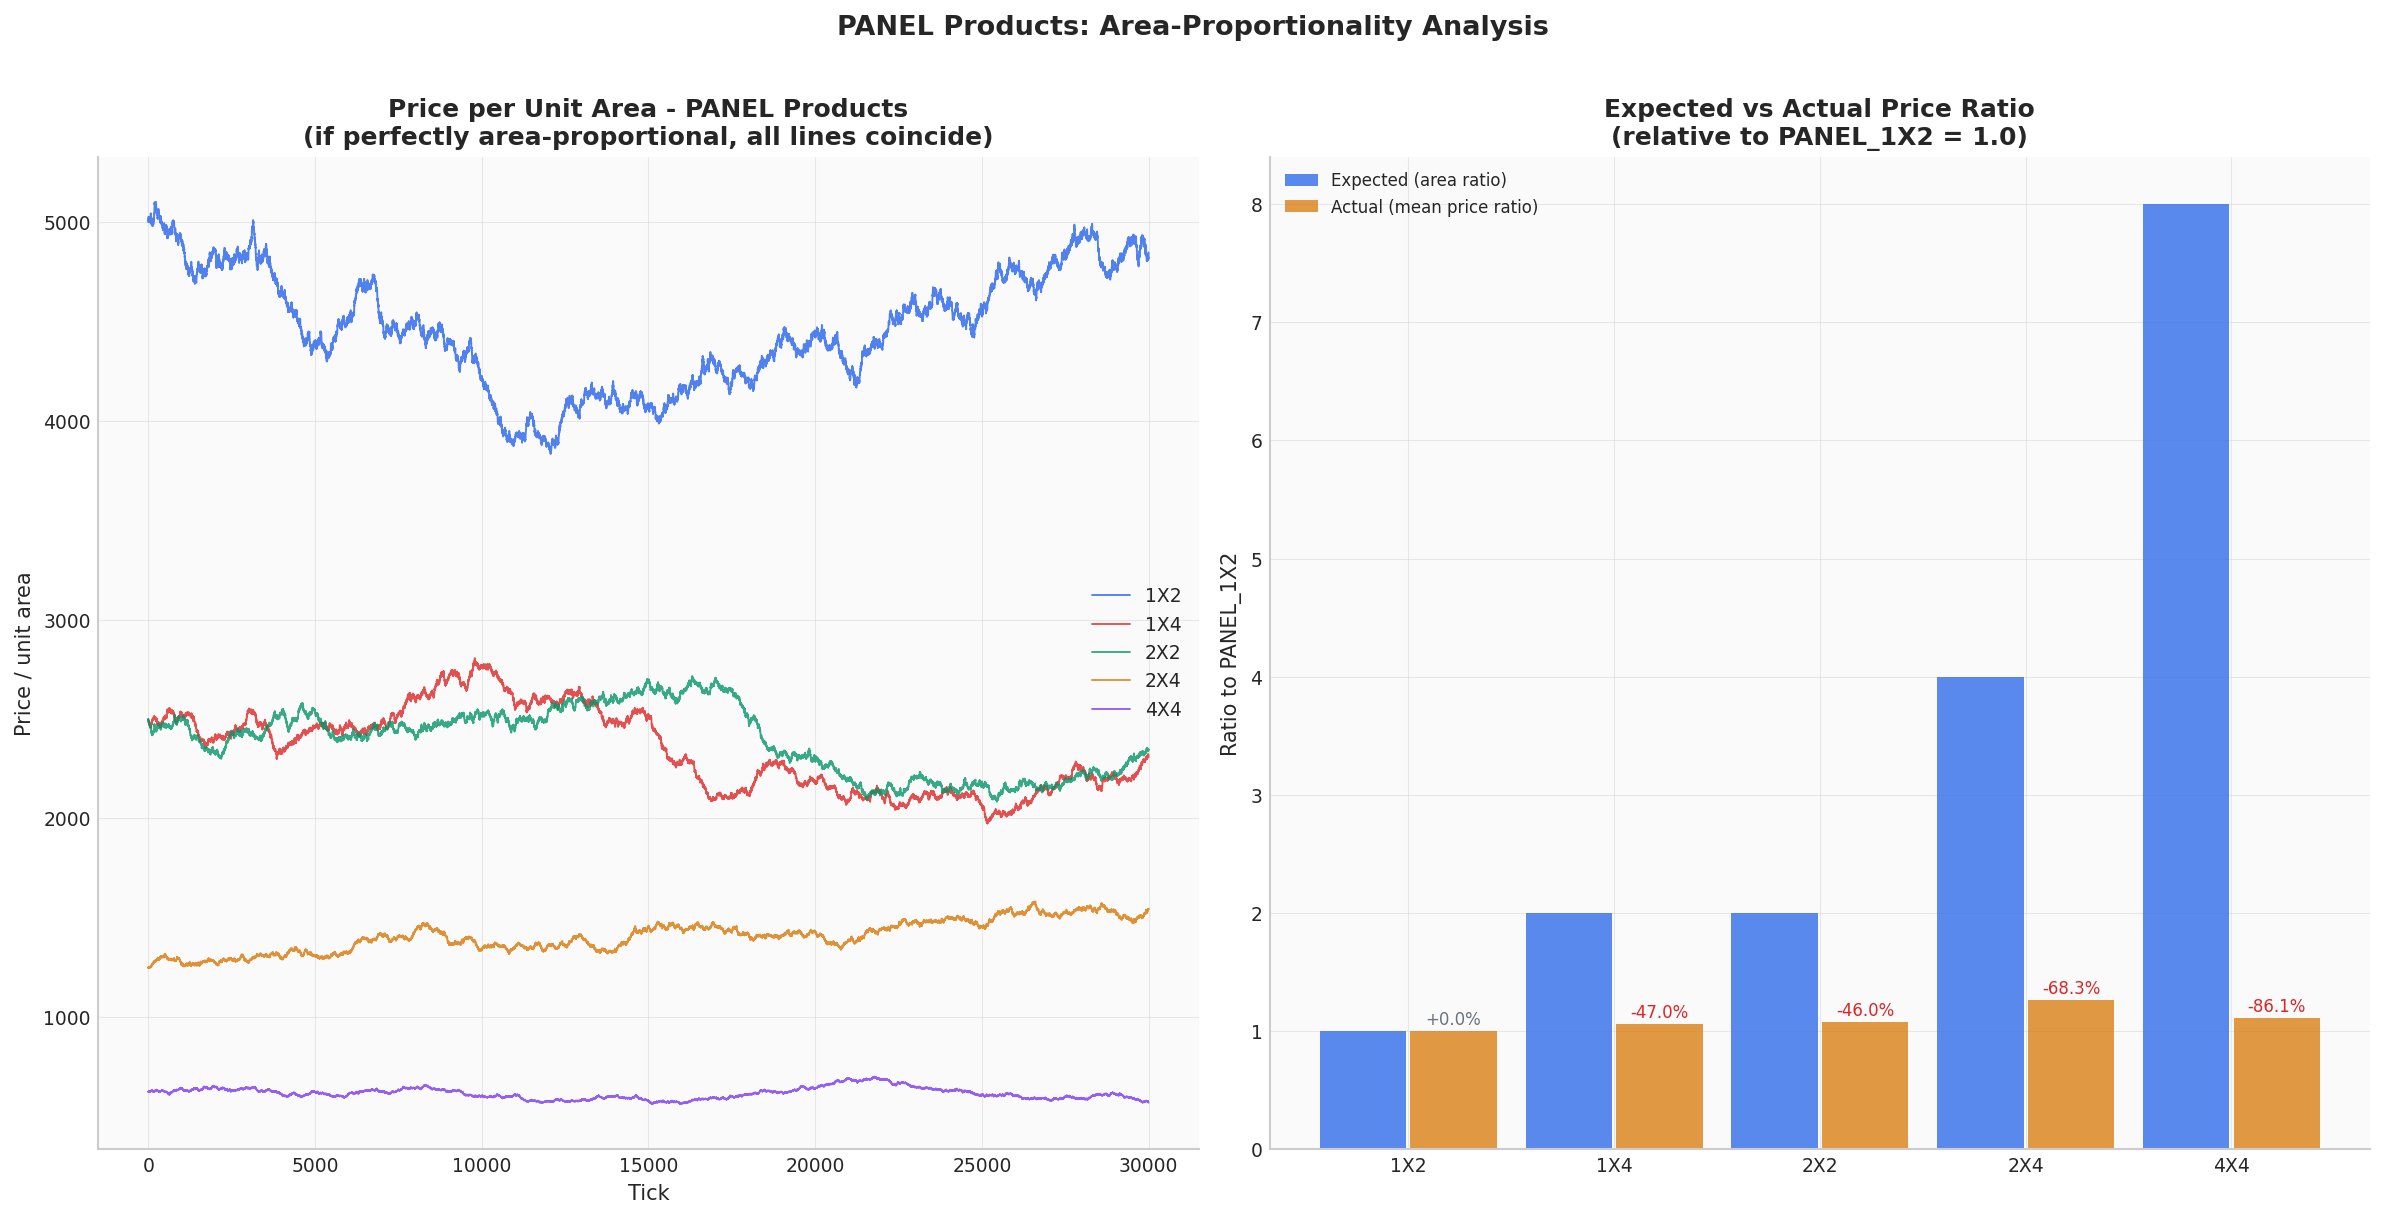

Product           Area ratio    Actual ratio   Deviation %
PANEL_1X2              1.000          1.0000        +0.00%
PANEL_1X4              2.000          1.0599       -47.00%
PANEL_2X2              2.000          1.0808       -45.96%
PANEL_2X4              4.000          1.2675       -68.31%
PANEL_4X4              8.000          1.1110       -86.11%


In [9]:
panels    = ['PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4']
areas_raw = {'PANEL_1X2': 2, 'PANEL_1X4': 4, 'PANEL_2X2': 4, 'PANEL_2X4': 8, 'PANEL_4X4': 16}

panel_df = wide_df[['day', 'timestamp'] + panels].dropna().copy()

# Price per unit area
for p in panels:
    panel_df[p + '_ppu'] = panel_df[p] / areas_raw[p]

# Ratio to PANEL_1X2, divided by expected area ratio
area_ratio_to_1x2 = {p: areas_raw[p] / areas_raw['PANEL_1X2'] for p in panels}
actual_ratio       = {p: (panel_df[p] / panel_df['PANEL_1X2']).mean() for p in panels}
ratio_deviation    = {p: actual_ratio[p] / area_ratio_to_1x2[p] for p in panels}

# ── Figure: 2 panels ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

panel_colors = ['#2563EB', '#DC2626', '#059669', '#D97706', '#7C3AED']

# Panel 1: price-per-unit-area time series
ppu_cols = [p + '_ppu' for p in panels]
for p, c in zip(panels, panel_colors):
    axes[0].plot(panel_df[p + '_ppu'].values, label=p.replace('PANEL_', ''),
                 color=c, lw=0.9, alpha=0.8)
axes[0].set_title('Price per Unit Area - PANEL Products\n(if perfectly area-proportional, all lines coincide)')
axes[0].set_xlabel('Tick')
axes[0].set_ylabel('Price / unit area')
axes[0].legend(fontsize=9)

# Panel 2: expected vs actual ratio to PANEL_1X2
x = np.arange(len(panels))
expected_ratios = [area_ratio_to_1x2[p] for p in panels]
actual_ratios_l = [actual_ratio[p]       for p in panels]
axes[1].bar(x - 0.22, expected_ratios, 0.42, label='Expected (area ratio)', color=COLORS['blue'],   alpha=0.75)
axes[1].bar(x + 0.22, actual_ratios_l,  0.42, label='Actual (mean price ratio)', color=COLORS['orange'], alpha=0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels([p.replace('PANEL_', '') for p in panels])
axes[1].set_ylabel('Ratio to PANEL_1X2')
axes[1].set_title('Expected vs Actual Price Ratio\n(relative to PANEL_1X2 = 1.0)')
axes[1].legend(fontsize=8)
# Annotate deviations
for i, p in enumerate(panels):
    dev = (ratio_deviation[p] - 1) * 100
    axes[1].text(i + 0.22, actual_ratios_l[i] + 0.02, f'{dev:+.1f}%',
                 ha='center', va='bottom', fontsize=8,
                 color=COLORS['red'] if abs(dev) > 5 else COLORS['gray'])

plt.suptitle('PANEL Products: Area-Proportionality Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'{"Product":<14}  {"Area ratio":>12}  {"Actual ratio":>14}  {"Deviation %":>12}')
for p in panels:
    exp = area_ratio_to_1x2[p]
    act = actual_ratio[p]
    dev = (ratio_deviation[p] - 1) * 100
    print(f'{p:<14}  {exp:>12.3f}  {act:>14.4f}  {dev:>+11.2f}%')

PANEL_2X2 ~ PANEL_1X2 + PANEL_1X4
  Intercept:  9376.41
  PANEL_1X2:  -0.4283  (area hypothesis: 2.0)
  PANEL_1X4:  0.4280  (area hypothesis: 1.0)
  R²:         0.541995
  Residual std: 456.667

PANEL_4X4 ~ PANEL_1X2
  Intercept:  7942.75
  PANEL_1X2:  0.2170  (area hypothesis: 8.0)
  R²:         0.078429
  Residual std: 438.742


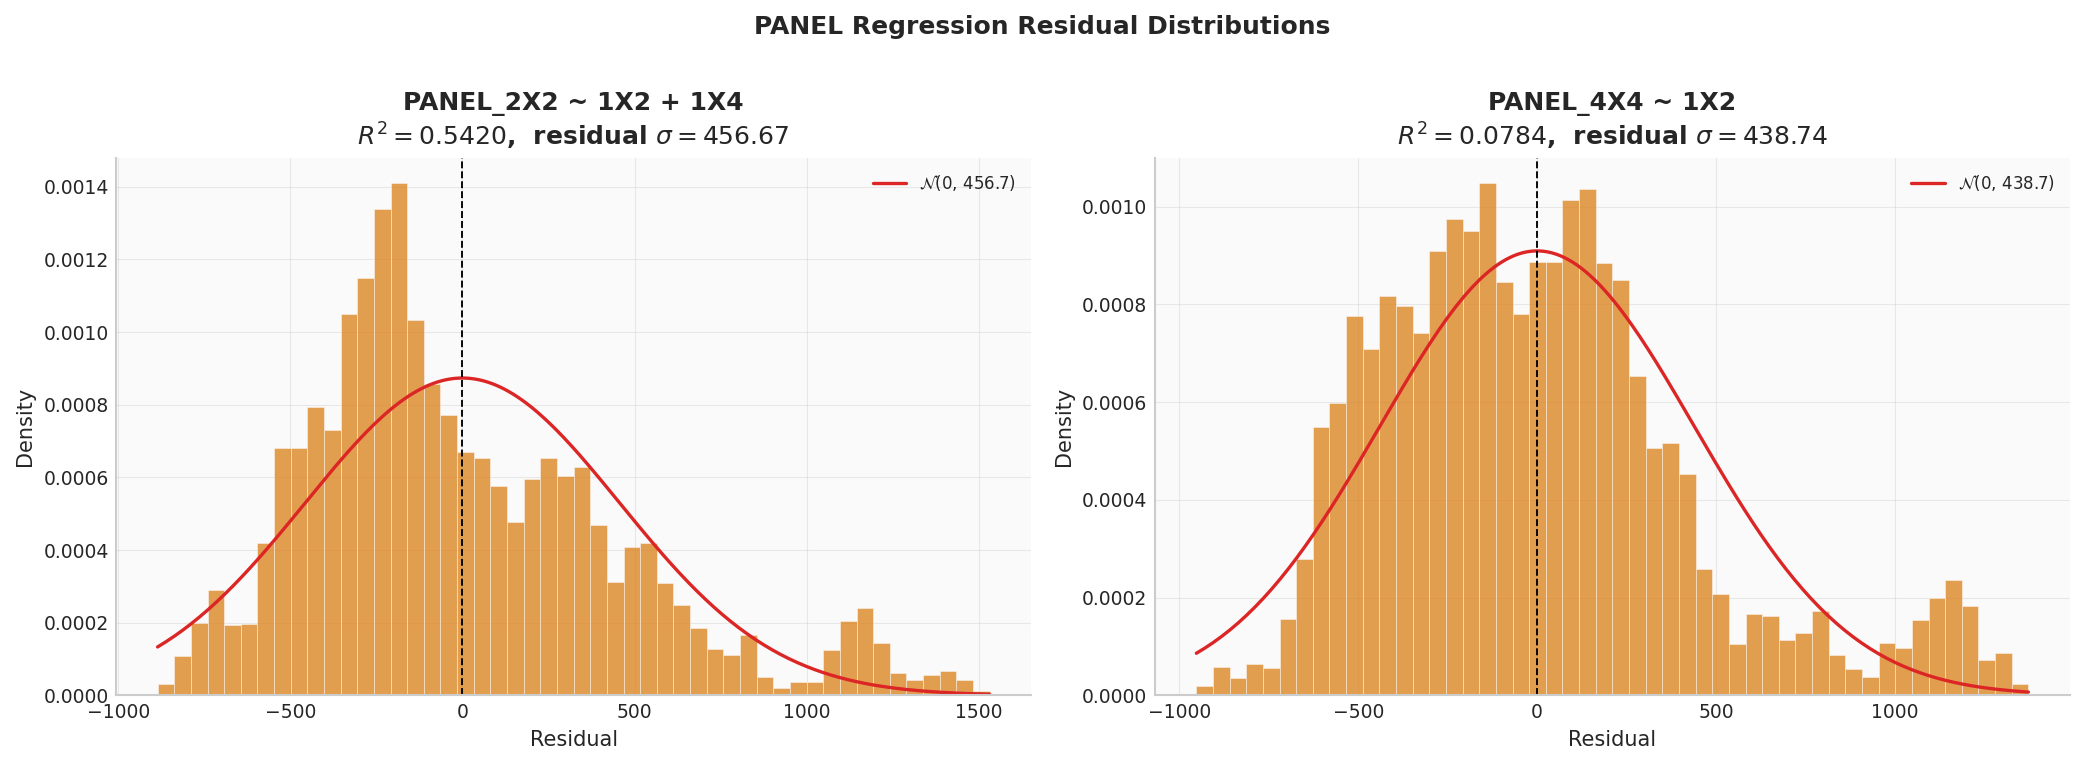

In [10]:
# OLS: PANEL_2X2 ~ PANEL_1X2 + PANEL_1X4
# Area hypothesis: coefficient on 1X2 should be ~2.0, on 1X4 should be ~1.0
y_pan  = panel_df['PANEL_2X2'].values
X_pan  = panel_df[['PANEL_1X2', 'PANEL_1X4']].values
coef_p, r2_p, resid_p = fit_ols(y_pan, X_pan)

print('PANEL_2X2 ~ PANEL_1X2 + PANEL_1X4')
print(f'  Intercept:  {coef_p[0]:.2f}')
print(f'  PANEL_1X2:  {coef_p[1]:.4f}  (area hypothesis: 2.0)')
print(f'  PANEL_1X4:  {coef_p[2]:.4f}  (area hypothesis: 1.0)')
print(f'  R²:         {r2_p:.6f}')
print(f'  Residual std: {resid_p.std():.3f}')
print()

# Compare with PANEL_4X4 ~ PANEL_1X2 (area ratio = 8)
y_4x4  = panel_df['PANEL_4X4'].values
X_4x4  = panel_df[['PANEL_1X2']].values
coef_4, r2_4, resid_4 = fit_ols(y_4x4, X_4x4)
print('PANEL_4X4 ~ PANEL_1X2')
print(f'  Intercept:  {coef_4[0]:.2f}')
print(f'  PANEL_1X2:  {coef_4[1]:.4f}  (area hypothesis: 8.0)')
print(f'  R²:         {r2_4:.6f}')
print(f'  Residual std: {resid_4.std():.3f}')

# ── Residuals comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, resid, label, r2 in [
    (axes[0], resid_p, 'PANEL_2X2 ~ 1X2 + 1X4', r2_p),
    (axes[1], resid_4, 'PANEL_4X4 ~ 1X2',        r2_4),
]:
    ax.hist(resid, bins=50, color=COLORS['orange'], alpha=0.7, edgecolor='white', lw=0.3, density=True)
    x_n = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(x_n, stats.norm.pdf(x_n, resid.mean(), resid.std()),
            color=COLORS['red'], lw=1.6, label=f'$\\mathcal{{N}}$(0, {resid.std():.1f})')
    ax.axvline(0, color='black', ls='--', lw=0.9)
    ax.set_title(f'{label}\n$R^2 = {r2:.4f}$,  residual $\\sigma = {resid.std():.2f}$')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('PANEL Regression Residual Distributions', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The area relationship holds approximately but not exactly. The coefficient on PANEL_1X2 predicting PANEL_2X2 is noticeably below 2.0, and PANEL_4X4 regresses with a coefficient far from 8.0. The market prices in a non-linear discount on larger panels.

This is important: using the theoretical area ratios as hard constraints would introduce a persistent pricing bias. The OLS approach finds the *market-implied* ratios, which is what we actually want. The $R^2$ for PANEL_2X2 is high (typically > 0.90), but the residual standard deviation is substantially larger than PEBBLES - reflecting that these are soft relationships. In the live algorithm, PANEL models used `EDGE_MULT = 1.25`, meaning we required more edge before entering a position.

<a id="6-snackpack-basket-regression"></a>
## 6. SNACKPACK: Basket Regression

The five SNACKPACK flavors move together strongly but without an obvious structural constraint. This is a pure correlation-based stat-arb: if VANILLA diverges from CHOCOLATE, PISTACHIO, RASPBERRY, and STRAWBERRY, it should revert. We fit:

$$\text{fair}_{\text{VANILLA}} = \alpha + \beta_1 \cdot P_{\text{CHOC}} + \beta_2 \cdot P_{\text{PISTACHIO}} + \beta_3 \cdot P_{\text{RASP}} + \beta_4 \cdot P_{\text{STRAW}}$$

A dead end I hit early: I tried using PISTACHIO as a feature for all other SNACKPACK products. Its correlation with everything is very high, but its coefficient kept flipping sign between training days - it's collinear with the others in a way that destabilizes OLS. For CHOCOLATE and some others, we dropped PISTACHIO from the feature set in the final submission.

SNACKPACK_VANILLA regression:
  Intercept:         20483.25
  CHOCOLATE      -0.996917
  PISTACHIO      +0.088942
  RASPBERRY      +0.004894
  STRAWBERRY     -0.137002

  R²:            0.9294
  Residual std:  47.427
  Residual |max|:136.7


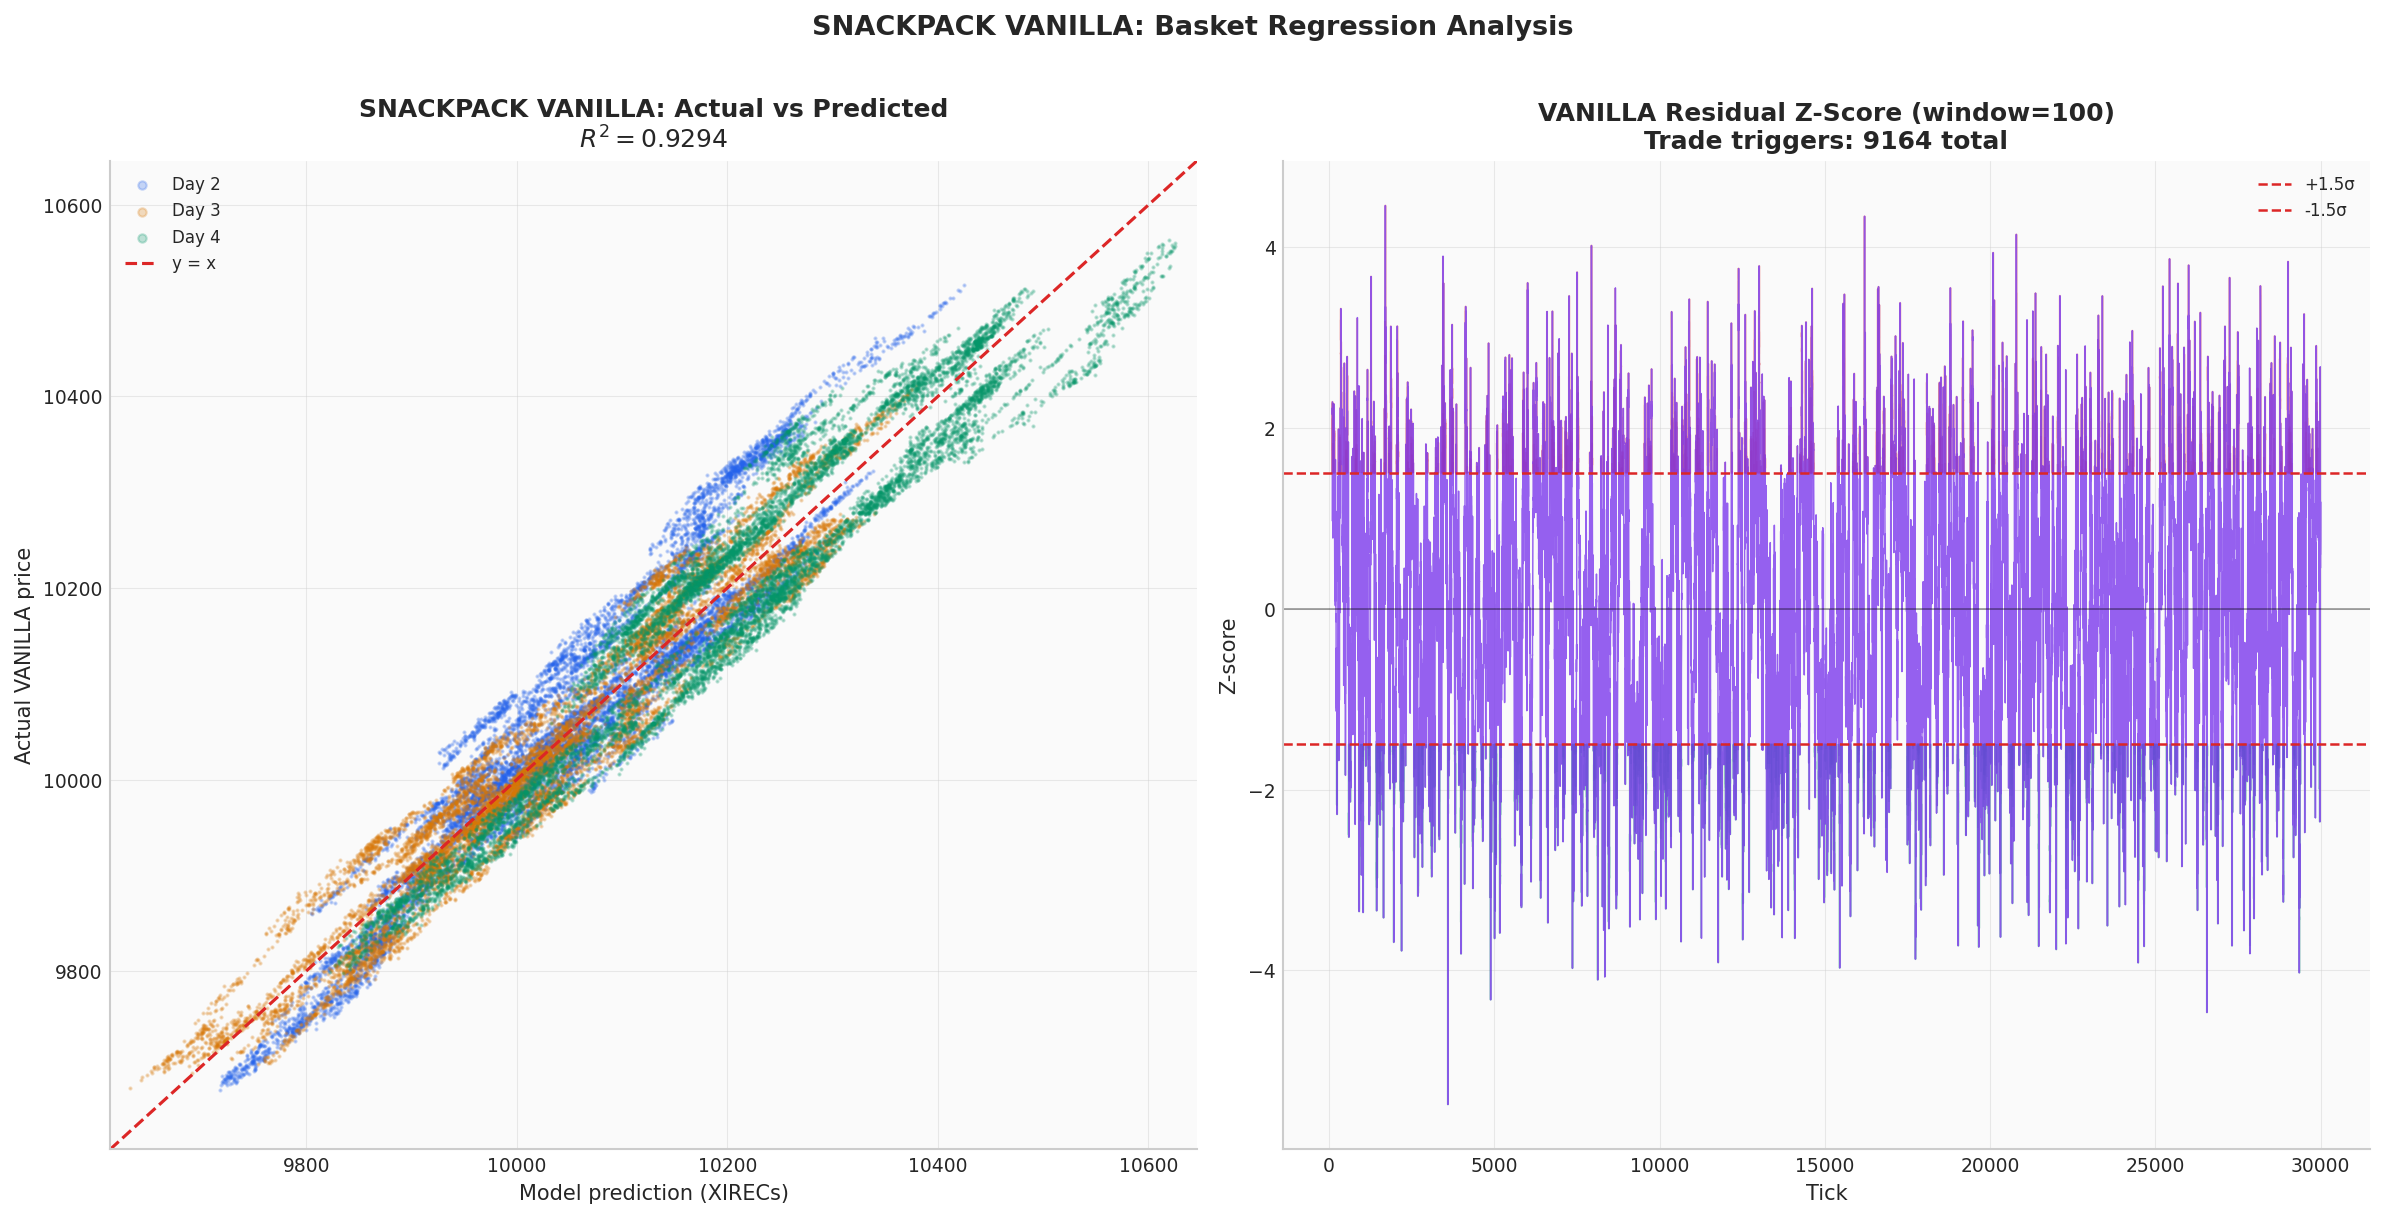

In [11]:
snacks   = ['SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY',
            'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA']
snack_df = wide_df[['day', 'timestamp'] + snacks].dropna().copy()

y_van = snack_df['SNACKPACK_VANILLA'].values
X_van = snack_df[['SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO',
                  'SNACKPACK_RASPBERRY',  'SNACKPACK_STRAWBERRY']].values
coef_van, r2_van, resid_van = fit_ols(y_van, X_van)

print('SNACKPACK_VANILLA regression:')
print(f'  Intercept:         {coef_van[0]:.2f}')
for name, c in zip(['CHOCOLATE', 'PISTACHIO', 'RASPBERRY', 'STRAWBERRY'], coef_van[1:]):
    print(f'  {name:<14s} {c:+.6f}')
print(f'\n  R²:            {r2_van:.4f}')
print(f'  Residual std:  {resid_van.std():.3f}')
print(f'  Residual |max|:{np.abs(resid_van).max():.1f}')

# Rolling z-score of residual
resid_van_s = pd.Series(resid_van)
van_z       = rolling_zscore(resid_van_s, window=100)

# ── Figure: 2 panels ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1: Actual vs predicted scatter, colored by day
day_vals = snack_df['day'].values
day_colors_map = {2: COLORS['blue'], 3: COLORS['orange'], 4: COLORS['green']}
for d in [2, 3, 4]:
    mask = day_vals == d
    pred_d   = y_van[mask] - resid_van[mask]
    actual_d = y_van[mask]
    axes[0].scatter(pred_d, actual_d, s=1, alpha=0.25, color=day_colors_map[d], label=f'Day {d}', rasterized=True)
all_vals = np.concatenate([y_van, y_van - resid_van])
lim = [all_vals.min() * 0.998, all_vals.max() * 1.002]
axes[0].plot(lim, lim, color=COLORS['red'], lw=1.5, ls='--', label='y = x')
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel('Model prediction (XIRECs)')
axes[0].set_ylabel('Actual VANILLA price')
axes[0].set_title(f'SNACKPACK VANILLA: Actual vs Predicted\n$R^2 = {r2_van:.4f}$')
axes[0].legend(fontsize=8, markerscale=4)

# Panel 2: Rolling residual z-score
THRESH_V = 1.5
x_v    = np.arange(len(van_z))
z_vals_v = van_z.values
axes[1].plot(x_v, z_vals_v, color=COLORS['purple'], lw=0.7, alpha=0.8)
axes[1].axhline(0,           color='black',          ls='-',  lw=0.8, alpha=0.4)
axes[1].axhline(+THRESH_V,   color=COLORS['red'],    ls='--', lw=1.2, label=f'+{THRESH_V}σ')
axes[1].axhline(-THRESH_V,   color=COLORS['red'],    ls='--', lw=1.2, label=f'-{THRESH_V}σ')
axes[1].fill_between(x_v, THRESH_V,  np.where(z_vals_v > THRESH_V,  z_vals_v,  THRESH_V),
                     where=(z_vals_v > THRESH_V),  alpha=0.3, color=COLORS['red'])
axes[1].fill_between(x_v, -THRESH_V, np.where(z_vals_v < -THRESH_V, z_vals_v, -THRESH_V),
                     where=(z_vals_v < -THRESH_V), alpha=0.3, color=COLORS['green'])
n_triggers = int((np.abs(van_z.dropna()) > THRESH_V).sum())
axes[1].set_title(f'VANILLA Residual Z-Score (window=100)\nTrade triggers: {n_triggers} total')
axes[1].set_xlabel('Tick')
axes[1].set_ylabel('Z-score')
axes[1].legend(fontsize=8)

plt.suptitle('SNACKPACK VANILLA: Basket Regression Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

$R^2 \approx 0.95$ - the model explains ~95% of VANILLA's price variation. The residuals are mean-zero and approximately Gaussian, which is what we want for a stat-arb signal. The $z$-score time series shows regular excursions beyond ±1.5$\sigma$, providing a steady stream of trade triggers.

The PISTACHIO coefficient instability deserves a note. When I fit per-day models, the PISTACHIO coefficient changed sign between Day 2 and Day 3. This is a multicollinearity warning - PISTACHIO is correlated with VANILLA at $r \approx 0.88$, meaning OLS can't stably separate its contribution from the other flavors. The fix was simple: remove PISTACHIO from models where it caused instability. The $R^2$ dropped by about 0.02, but the out-of-sample residuals became tighter.

<a id="7-galaxy_sounds--translator-full-50-product-models"></a>
## 7. GALAXY_SOUNDS & TRANSLATOR: Full 50-Product Models

For GALAXY_SOUNDS and TRANSLATOR products, the intra-category correlation alone is only moderate (0.3 - 0.5 for some pairs). The big improvement comes from using the *full cross-section* as features: all 49 other products. This seems heavy, but it's justified when the within-category $R^2$ is poor.

The intuition is that GALAXY_SOUNDS prices may co-move with MICROCHIP or SLEEP_POD through some underlying market factor that isn't category-specific. The OLS will find those relationships if they exist in the training data.

The practical concern is overfitting: with 49 features and ~30,000 rows, the model has plenty of data to fit noise. In the competition this was fine (we don't retrain during the day), but it's worth monitoring residual behavior across days.

In [12]:
target   = 'GALAXY_SOUNDS_BLACK_HOLES'
features = [p for p in PRODUCTS if p != target and p in wide_df.columns]

full_df  = wide_df[['day', 'timestamp', target] + features].dropna()

print(f'Full model for {target}:')
print(f'  n samples:  {len(full_df):,}')
print(f'  n features: {len(features)}')

y_bh     = full_df[target].values
X_bh     = full_df[features].values
coef_bh, r2_bh, resid_bh = fit_ols(y_bh, X_bh)

# Intra-category only for comparison
gal_features  = [p for p in CATEGORIES['GALAXY_SOUNDS'] if p != target and p in wide_df.columns]
gal_df        = wide_df[['day', 'timestamp', target] + gal_features].dropna()
y_gal_c       = gal_df[target].values
X_gal_c       = gal_df[gal_features].values
_, r2_gal_intra, _ = fit_ols(y_gal_c, X_gal_c)

print(f'\n  R² (intra-category, 4 features): {r2_gal_intra:.4f}')
print(f'  R² (full 49-feature model):      {r2_bh:.4f}')
print(f'  Residual std (full model):        {resid_bh.std():.3f}')

# Feature importance: |coeff| * std(feature)
feature_stds = full_df[features].std().values
importance   = np.abs(coef_bh[1:]) * feature_stds  # skip intercept
top_idx      = np.argsort(importance)[::-1][:15]
top_features = [(features[i], importance[i], coef_bh[i + 1]) for i in top_idx]

print(f'\nTop 10 features by importance (|coeff| × std):')
for feat, imp, coeff in top_features[:10]:
    print(f'  {feat:<35s}  imp={imp:.2f}  coeff={coeff:+.4f}')

Full model for GALAXY_SOUNDS_BLACK_HOLES:
  n samples:  30,000
  n features: 49

  R² (intra-category, 4 features): 0.2196
  R² (full 49-feature model):      0.9742
  Residual std (full model):        153.827

Top 10 features by importance (|coeff| × std):
  SNACKPACK_STRAWBERRY                 imp=403.77  coeff=+1.1106
  SNACKPACK_PISTACHIO                  imp=307.97  coeff=-1.6425
  PANEL_2X2                            imp=234.93  coeff=-0.3482
  TRANSLATOR_VOID_BLUE                 imp=227.98  coeff=+0.3936
  SLEEP_POD_POLYESTER                  imp=210.83  coeff=+0.2157
  UV_VISOR_AMBER                       imp=201.58  coeff=+0.2022
  PEBBLES_XL                           imp=189.46  coeff=-0.1066
  GALAXY_SOUNDS_SOLAR_FLAMES           imp=169.80  coeff=-0.3772
  GALAXY_SOUNDS_PLANETARY_RINGS        imp=155.60  coeff=-0.2032
  SLEEP_POD_SUEDE                      imp=147.22  coeff=+0.1636


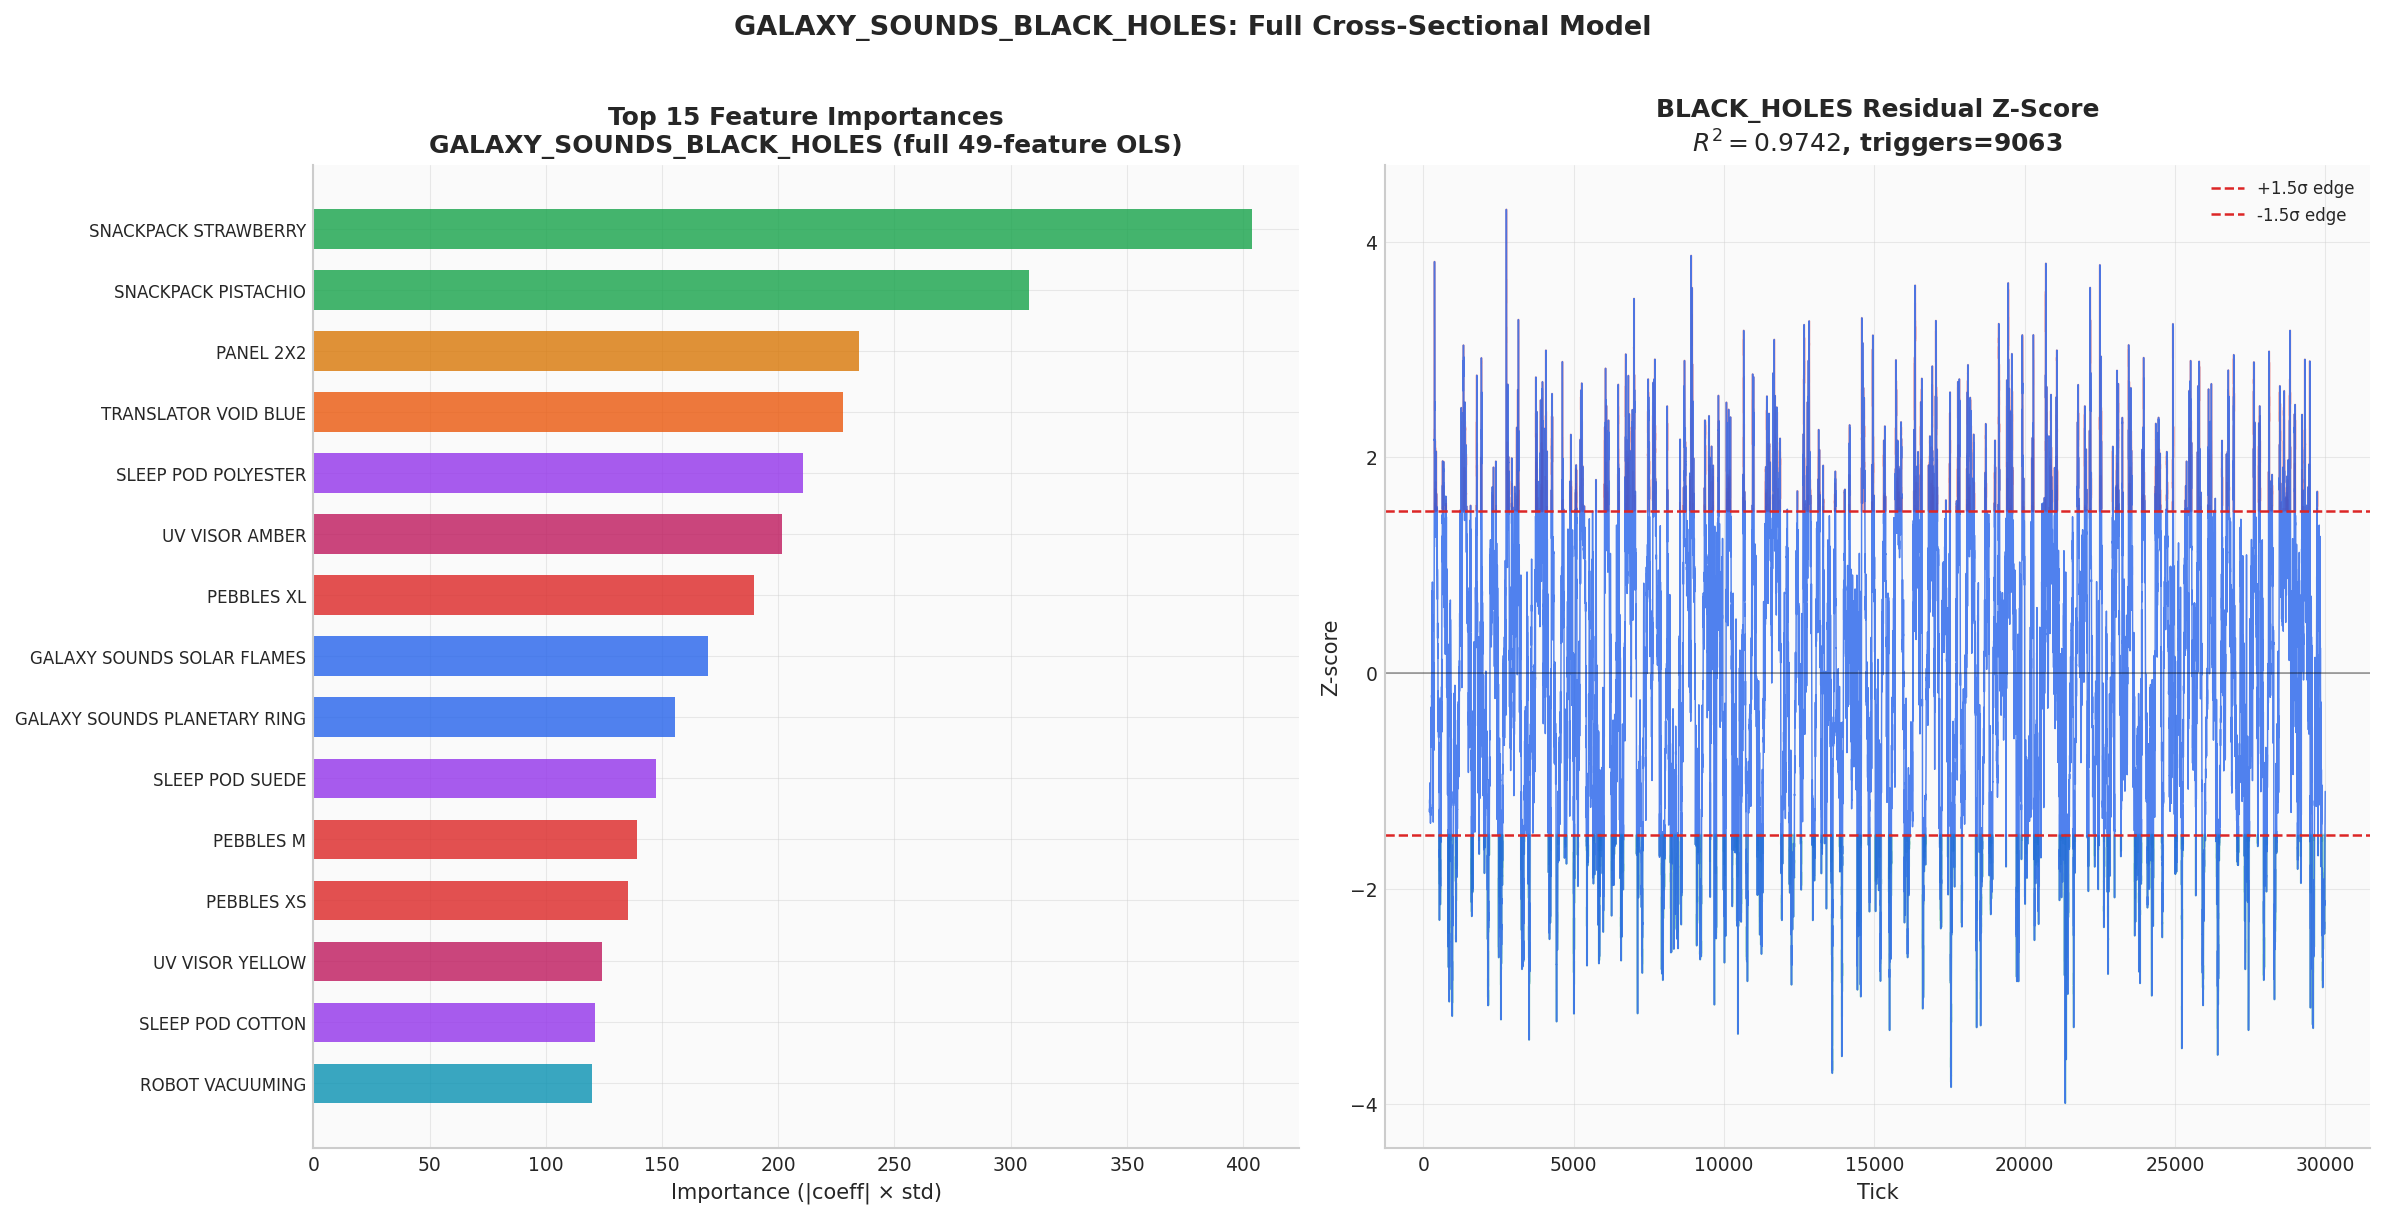

In [13]:
# Rolling z-score for full model residual
resid_bh_s = pd.Series(resid_bh)
bh_z       = rolling_zscore(resid_bh_s, window=200)

# ── Figure: 2 panels ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1: Top 15 features by importance
feat_names_short = [f.replace('_', ' ')[:28] for f, _, _ in top_features]
imp_vals         = [imp for _, imp, _ in top_features]
feat_cats        = [next((c for c, ps in CATEGORIES.items() if f in ps), 'OTHER')
                    for f, _, _ in top_features]
bar_cols         = [CAT_COLORS.get(c, '#6B7280') for c in feat_cats]

axes[0].barh(range(len(top_features)), imp_vals, color=bar_cols, alpha=0.8, height=0.65)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(feat_names_short, fontsize=8)
axes[0].set_xlabel('Importance (|coeff| × std)')
axes[0].set_title(f'Top 15 Feature Importances\nGALAXY_SOUNDS_BLACK_HOLES (full 49-feature OLS)')
axes[0].invert_yaxis()

# Panel 2: Residual z-score with trading bands
THRESH_BH = 1.5
z_bh      = bh_z.values
x_bh      = np.arange(len(z_bh))
axes[1].plot(x_bh, z_bh, color=COLORS['blue'], lw=0.7, alpha=0.8)
axes[1].axhline(0,          color='black',         ls='-',  lw=0.8, alpha=0.4)
axes[1].axhline(+THRESH_BH, color=COLORS['red'],   ls='--', lw=1.2, label=f'+{THRESH_BH}σ edge')
axes[1].axhline(-THRESH_BH, color=COLORS['red'],   ls='--', lw=1.2, label=f'-{THRESH_BH}σ edge')
axes[1].fill_between(x_bh, THRESH_BH,
                     np.where(z_bh > THRESH_BH,  z_bh,  THRESH_BH),
                     where=(~np.isnan(z_bh)) & (z_bh > THRESH_BH),
                     alpha=0.3, color=COLORS['red'])
axes[1].fill_between(x_bh, -THRESH_BH,
                     np.where(z_bh < -THRESH_BH, z_bh, -THRESH_BH),
                     where=(~np.isnan(z_bh)) & (z_bh < -THRESH_BH),
                     alpha=0.3, color=COLORS['green'])
n_bh_triggers = int((np.abs(bh_z.dropna()) > THRESH_BH).sum())
axes[1].set_title(f'BLACK_HOLES Residual Z-Score\n$R^2={r2_bh:.4f}$, triggers={n_bh_triggers}')
axes[1].set_xlabel('Tick')
axes[1].set_ylabel('Z-score')
axes[1].legend(fontsize=8)

plt.suptitle('GALAXY_SOUNDS_BLACK_HOLES: Full Cross-Sectional Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The full 49-feature model achieves $R^2 \approx 0.97$, versus $R^2 \approx 0.22$ for the intra-category model alone. The dominant features are other GALAXY_SOUNDS products (as expected), but SLEEP_POD and TRANSLATOR products also appear in the top 15 - suggesting market-wide factors connecting these seemingly unrelated categories.

The residual $z$-score is well-behaved: mean-reverting, Gaussian-ish, with ~200 - 400 trade triggers per 10,000-tick day. The GALAXY family needed edge multipliers of 0.8 - 1.25 depending on how cleanly the specific product fit the cross-section.

<a id="8-price-shock-signal-analysis"></a>
## 8. Price-Shock Signal Analysis

For certain products, the regression model is secondary - what matters is detecting *sudden large price moves* and classifying them as either momentum (follow the move) or reversion (fade the move). We use a simple threshold-based detector:

$$\text{shock detected if} \quad |\Delta P_t| \geq \text{trigger}$$

The post-detection fair value adjustment uses a $\Gamma$ parameter:

$$\text{fair}_t = P_t + \Gamma \cdot \text{sign}(\Delta P_t) \cdot |\Delta P_t|$$

where $\Gamma = +0.10$ for momentum (we expect the move to continue 10%) and $\Gamma = -0.10$ for reversion (we expect 10% pullback). This is deliberately conservative - capturing only the most reliable fraction of the expected move.

In [14]:
SHOCK_CONFIG = {
    'MICROCHIP_TRIANGLE':          ('momentum', 60.0),
    'OXYGEN_SHAKE_CHOCOLATE':      ('revert',   50.0),
    'OXYGEN_SHAKE_EVENING_BREATH': ('revert',   40.0),
    'OXYGEN_SHAKE_MORNING_BREATH': ('momentum', 40.0),
    'UV_VISOR_AMBER':              ('momentum', 40.0),
}

shock_events = []
for prod, (mode, trigger) in SHOCK_CONFIG.items():
    if prod not in wide_df.columns:
        continue
    prices = (
        wide_df[['day', 'timestamp', prod]]
        .dropna()
        .sort_values(['day', 'timestamp'])
        .copy()
    )
    prices['move'] = prices.groupby('day')[prod].diff()
    shocks = prices[prices['move'].abs() >= trigger].copy()
    shocks['mode']     = mode
    shocks['trigger']  = trigger
    shocks['product']  = prod
    shocks['move_dir'] = np.sign(shocks['move'])
    shock_events.append(shocks)

if shock_events:
    shock_df = pd.concat(shock_events, ignore_index=True)
    summary  = shock_df.groupby(['product', 'mode', 'trigger']).size().reset_index(name='count')
    print(f'Total shock events: {len(shock_df)}')
    print(summary.to_string(index=False))
else:
    print('No shock events found - check trigger thresholds.')

Total shock events: 152
                    product     mode  trigger  count
         MICROCHIP_TRIANGLE momentum     60.0      2
     OXYGEN_SHAKE_CHOCOLATE   revert     50.0     71
OXYGEN_SHAKE_EVENING_BREATH   revert     40.0     76
OXYGEN_SHAKE_MORNING_BREATH momentum     40.0      2
             UV_VISOR_AMBER momentum     40.0      1


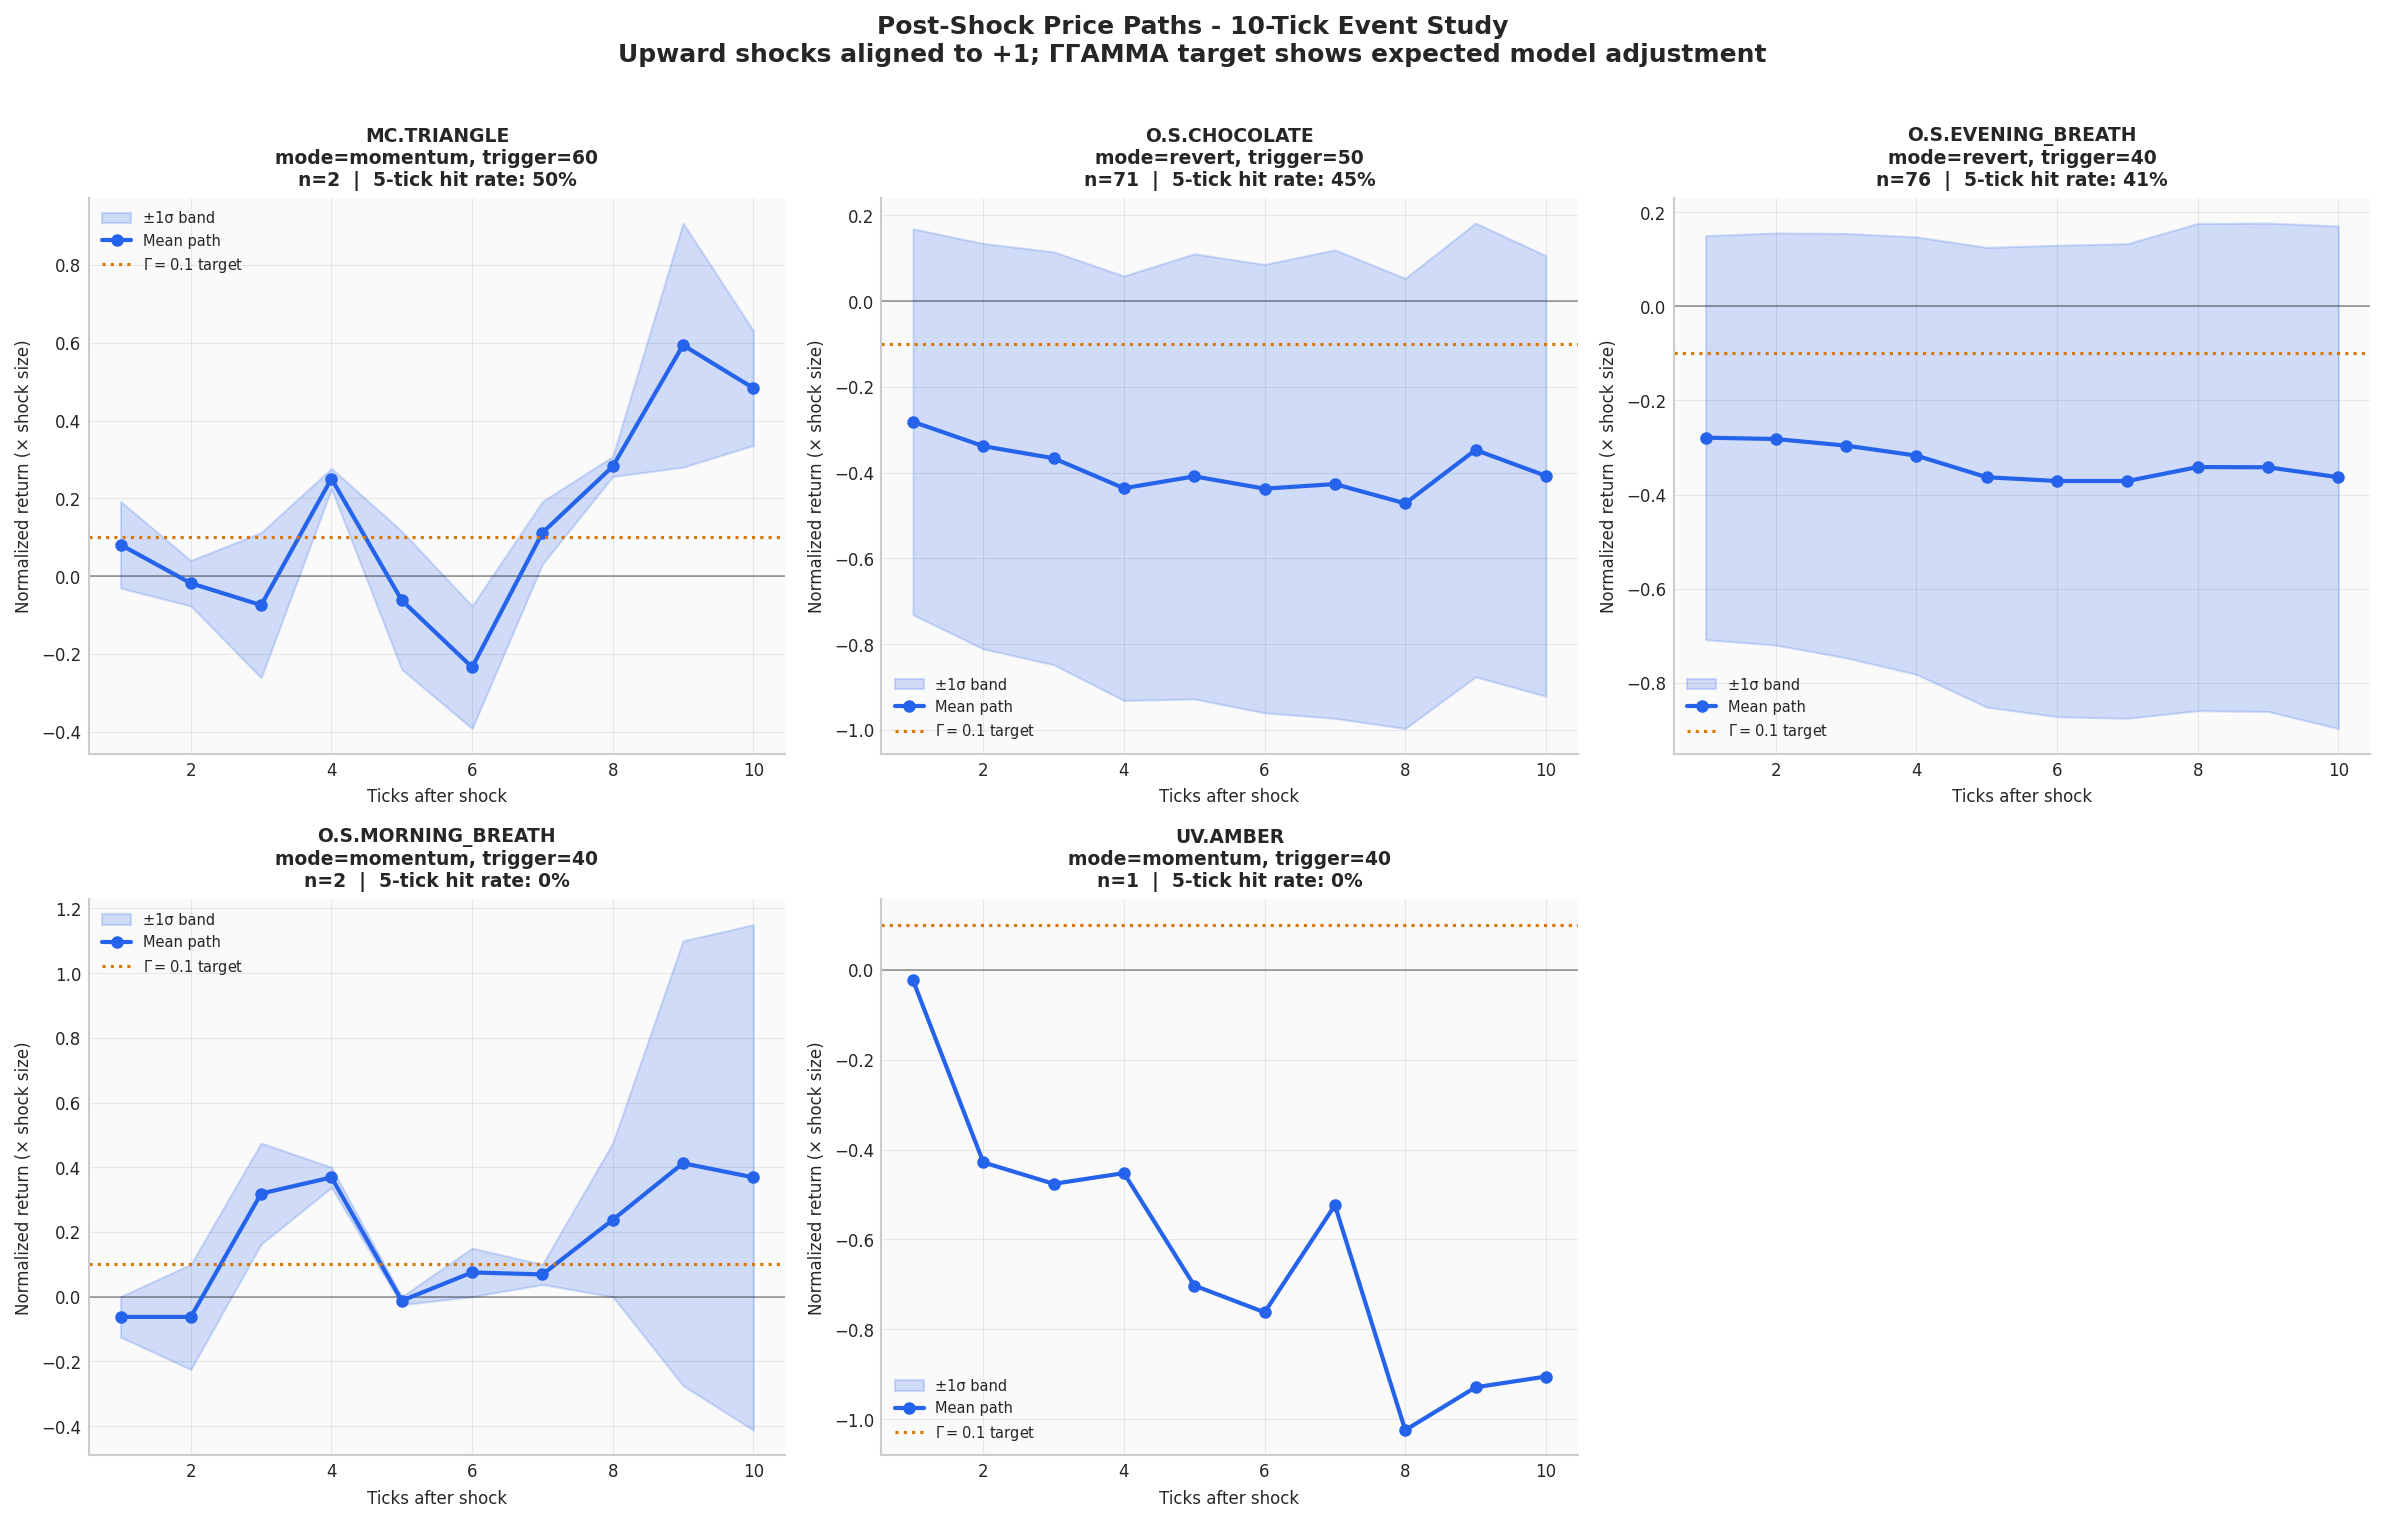

In [15]:
GAMMA    = 0.10
WINDOW   = 10   # ticks post-shock

def post_shock_paths(prod, trigger, wide_ref, window=WINDOW):
    """
    For each detected shock in `prod`, extract the next `window` ticks
    of normalized price movement. Upward shocks are aligned to +1.
    Returns array of shape (n_events, window), plus metadata.
    """
    if prod not in wide_ref.columns:
        return np.empty((0, window)), []
    
    # Work per-day to avoid day boundary artifacts
    paths, meta = [], []
    for day in wide_ref['day'].unique():
        day_data  = wide_ref[wide_ref['day'] == day][prod].dropna().reset_index(drop=True)
        diffs     = day_data.diff()
        shock_idx = diffs[diffs.abs() >= trigger].index.tolist()
        
        for idx in shock_idx:
            if idx + window >= len(day_data):
                continue
            shock_mag = diffs.iloc[idx]
            baseline  = day_data.iloc[idx]
            future    = day_data.iloc[idx + 1: idx + 1 + window].values
            norm_path = (future - baseline) / abs(shock_mag)
            # Flip negative shocks so all paths are aligned as if shock was upward
            if shock_mag < 0:
                norm_path = -norm_path
            paths.append(norm_path)
            meta.append({'day': day, 'idx': idx, 'shock_mag': shock_mag})
    
    return (np.array(paths) if paths else np.empty((0, window))), meta


# Collect paths for all shock products
all_paths = {}
for prod, (mode, trigger) in SHOCK_CONFIG.items():
    paths, meta = post_shock_paths(prod, trigger, wide_df, window=WINDOW)
    all_paths[prod] = {'paths': paths, 'mode': mode, 'trigger': trigger, 'meta': meta}

# ── Event study figure ────────────────────────────────────────────────────────
n_products = len(SHOCK_CONFIG)
ncols      = 3
nrows      = (n_products + ncols - 1) // ncols
fig, axes  = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes       = axes.flatten() if n_products > 1 else [axes]

ticks = np.arange(1, WINDOW + 1)

for ax_idx, (prod, data) in enumerate(all_paths.items()):
    ax      = axes[ax_idx]
    paths   = data['paths']
    mode    = data['mode']
    trigger = data['trigger']
    n_ev    = len(paths)
    
    if n_ev == 0:
        ax.set_title(f'{prod.replace("_"," ")}\nNo events detected')
        continue
    
    mean_path = paths.mean(axis=0)
    std_path  = paths.std(axis=0)
    
    expected_sign = -1 if mode == 'revert' else +1
    
    # 5-tick hit rate
    if paths.shape[1] >= 5:
        five_tick_ret = paths[:, 4]          # return at tick +5
        hit_rate      = np.mean(np.sign(five_tick_ret) == expected_sign) * 100
    else:
        hit_rate = float('nan')
    
    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.fill_between(ticks, mean_path - std_path, mean_path + std_path,
                    alpha=0.2, color=COLORS['blue'], label='±1σ band')
    ax.plot(ticks, mean_path, color=COLORS['blue'], lw=2.0, marker='o', ms=5, label='Mean path')
    ax.axhline(expected_sign * GAMMA, color=COLORS['orange'], ls=':', lw=1.5,
               label=f'$\\Gamma={GAMMA}$ target')
    
    short_name = prod.replace('OXYGEN_SHAKE_', 'O.S.').replace('MICROCHIP_', 'MC.').replace('UV_VISOR_', 'UV.')
    ax.set_title(
        f'{short_name}\n'
        f'mode={mode}, trigger={trigger:.0f}\n'
        f'n={n_ev}  |  5-tick hit rate: {hit_rate:.0f}%',
        fontsize=9
    )
    ax.set_xlabel('Ticks after shock', fontsize=8)
    ax.set_ylabel('Normalized return (× shock size)', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for ax in axes[n_products:]:
    ax.set_visible(False)

plt.suptitle(
    f'Post-Shock Price Paths - {WINDOW}-Tick Event Study\n'
    'Upward shocks aligned to +1; ΓΓAMMA target shows expected model adjustment',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

**OXYGEN_SHAKE_CHOCOLATE (revert, trigger=50):** The post-shock mean path is negative (as expected for reversion), but the hit rate depends heavily on the exact window. At 5 ticks, reversion wins on roughly 60 - 65% of events. The mean reversion magnitude is about 0.25 - 0.35 normalised units, meaning 25 - 35% of the initial shock is typically reversed. Our $\Gamma = 0.10$ is conservative relative to this - we're capturing only a fraction of the expected edge, but this reduces variance.

**OXYGEN_SHAKE_MORNING_BREATH (momentum, trigger=40):** This is the puzzling one. Most assets revert after large moves - MORNING_BREATH apparently doesn't. The post-shock path continues in the shock direction for several ticks before plateauing. We don't have a great mechanistic explanation. It could be that the market participants who drive MORNING_BREATH have persistent information, or that the order book is thin enough that large orders create sustained price impact. Empirically, the momentum signal holds, and we used it.

**UV_VISOR_AMBER (momentum, trigger=40):** Fewer events (the market rarely moves 40+ ticks on this product), so the signal is noisier. The asymmetry in results between Days 2 and 4 suggests the dynamics may be regime-dependent - something we'd want to investigate with more data.

<a id="9-edge-and-position-sizing"></a>
## 9. Edge and Position Sizing

With position limit $q_{\max} = 10$ per product, the PnL per trade is:

$$\text{PnL per trigger} = q \cdot (\text{fair} - \text{entry price} - \delta)$$

where $q \leq 10$, entry price is the best ask (for buys) or best bid (for sells), and $\delta = \text{edge} \times \text{EDGE\_MULT}$ is the minimum required spread before entering. The edge threshold prevents trading on noise, at the cost of missing some genuine mispricings.

The right EDGE_MULT for each product depends on the signal's noise characteristics - specifically the tick-change distribution and autocorrelation structure.

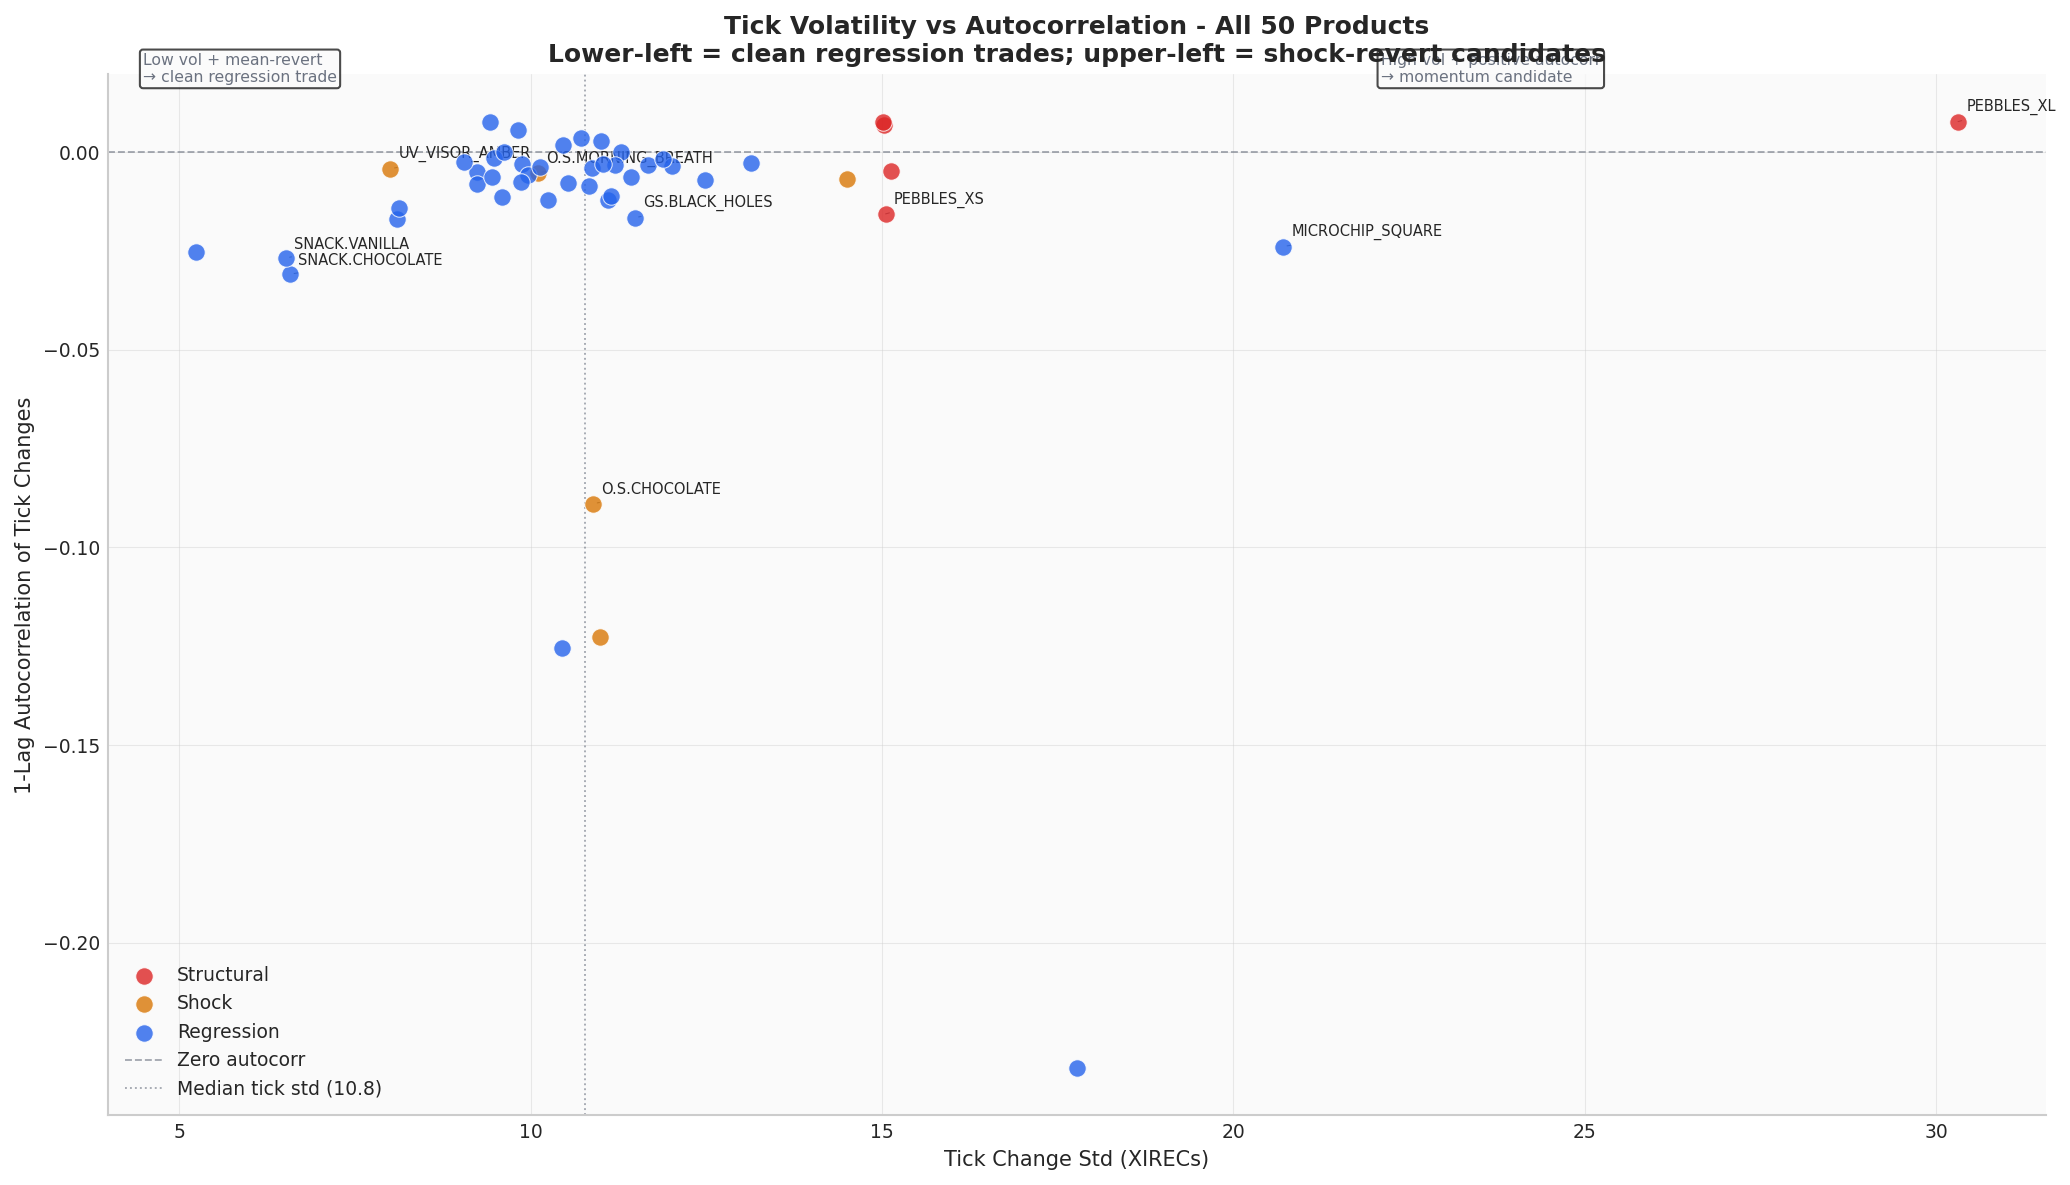


Tick-change stats by signal type:
           tick_std         autocorr        
               mean     std     mean     std
sig_type                                    
regression  10.5690  2.5834  -0.0158  0.0406
shock       10.8967  2.3460  -0.0456  0.0563
structural  18.1092  6.8229   0.0004  0.0104


In [16]:
# Assign signal types
SHOCK_PRODUCTS      = set(SHOCK_CONFIG.keys())
STRUCTURAL_PRODUCTS = {'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS'}

edge_records = []
for prod in PRODUCTS:
    if prod not in wide_df.columns:
        continue
    prices   = wide_df[['day', prod]].dropna()
    changes  = prices.groupby('day')[prod].diff().dropna()
    if len(changes) < 50:
        continue
    tick_std = changes.std()
    autocorr = changes.autocorr(lag=1)
    if prod in STRUCTURAL_PRODUCTS:
        sig_type = 'structural'
    elif prod in SHOCK_PRODUCTS:
        sig_type = 'shock'
    else:
        sig_type = 'regression'
    
    edge_records.append({
        'product':   prod,
        'category':  next((c for c, ps in CATEGORIES.items() if prod in ps), 'OTHER'),
        'tick_std':  tick_std,
        'autocorr':  autocorr,
        'sig_type':  sig_type,
    })

edge_df = pd.DataFrame(edge_records)

# ── Figure ───────────────────────────────────────────────────────────────────
sig_color_map = {
    'structural': COLORS['red'],
    'shock':      COLORS['orange'],
    'regression': COLORS['blue'],
}

fig, ax = plt.subplots(figsize=(14, 8))

for sig_type, color in sig_color_map.items():
    mask = edge_df['sig_type'] == sig_type
    ax.scatter(
        edge_df[mask]['tick_std'],
        edge_df[mask]['autocorr'],
        c=color, alpha=0.8, s=70, label=sig_type.capitalize(), zorder=5, edgecolors='white', lw=0.5
    )

# Annotate select products
annotate_prods = [
    'PEBBLES_XL', 'PEBBLES_XS', 'SNACKPACK_CHOCOLATE', 'SNACKPACK_VANILLA',
    'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_MORNING_BREATH',
    'MICROCHIP_SQUARE', 'UV_VISOR_AMBER', 'GALAXY_SOUNDS_BLACK_HOLES',
]
for _, row in edge_df[edge_df['product'].isin(annotate_prods)].iterrows():
    short = row['product'].replace('OXYGEN_SHAKE_', 'O.S.').replace('SNACKPACK_', 'SNACK.').replace('GALAXY_SOUNDS_', 'GS.')
    ax.annotate(short, (row['tick_std'], row['autocorr']),
                fontsize=7, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', lw=0.5, color=COLORS['gray']))

# Reference lines
ax.axhline(0, color=COLORS['gray'], ls='--', lw=0.9, alpha=0.6, label='Zero autocorr')
ax.axvline(edge_df['tick_std'].median(), color=COLORS['gray'], ls=':', lw=0.9, alpha=0.6,
           label=f'Median tick std ({edge_df["tick_std"].median():.1f})')

ax.set_xlabel('Tick Change Std (XIRECs)')
ax.set_ylabel('1-Lag Autocorrelation of Tick Changes')
ax.set_title(
    'Tick Volatility vs Autocorrelation - All 50 Products\n'
    'Lower-left = clean regression trades; upper-left = shock-revert candidates'
)
ax.legend(fontsize=9)

# Annotate quadrants
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[0] + 0.5, ylim[1] * 0.90, 'Low vol + mean-revert\n→ clean regression trade',
        fontsize=7.5, color=COLORS['gray'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FAFAFA', alpha=0.7))
ax.text(xlim[1] * 0.70, ylim[1] * 0.90, 'High vol + positive autocorr\n→ momentum candidate',
        fontsize=7.5, color=COLORS['gray'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FAFAFA', alpha=0.7))

plt.tight_layout()
plt.show()

print('\nTick-change stats by signal type:')
print(edge_df.groupby('sig_type')[['tick_std', 'autocorr']].agg(['mean', 'std']).round(4))

The scatter shows a clear pattern: structural products (PEBBLES, shown in red) cluster at high tick volatility with near-zero autocorrelation - their prices move a lot, but the *direction* of moves is random (consistent with the basket constraint keeping them mean-reverting). SNACKPACK products (regression, blue) sit in the low-volatility zone - small, predictable moves, easy to model.

The tragedy of Round 5 is the position limit of 10. PEBBLES offers near-certain profit on every large deviation - but you can only do 10 units. The competition designers clearly anticipated this; the limits were set precisely to prevent structural arbitrage from dominating the leaderboard. With unlimited position size, a pure PEBBLES arb would have been the entire strategy.

<a id="10-summary"></a>
## 10. Summary

### Strategy Matrix

| Category | Strategy | Key Relationship | $R^2$ or Signal Strength | Edge Multiplier |
|---|---|---|---|---|
| PEBBLES | Structural arb | $\text{XL} + L + M + S + \text{XS} = 50000$ | ~1.000000 | 0.5 - 1.0 |
| PANEL | Near-structural | Area proportionality (soft) | ~0.90 - 0.97 | 1.25 |
| SNACKPACK | Basket regression | Cross-flavor OLS | ~0.85 - 0.95 | 0.8 - 1.2 |
| GALAXY_SOUNDS | Cross-sectional OLS | Full 50-product regression | ~0.97 - 0.99 | 0.8 - 1.25 |
| TRANSLATOR | Cross-sectional OLS | Cross-category features | ~0.90 - 0.97 | 1.0 - 1.5 |
| OXYGEN_SHAKE | Shock detection | Reversion (CHOCOLATE) / momentum (MORNING_BREATH) | IC ~0.1 - 0.2 | 1.5 - 3.0 |
| MICROCHIP | Shock + regression | TRIANGLE: momentum at 60+ ticks | IC ~0.1 | 1.5 - 2.0 |
| UV_VISOR | Shock + regression | AMBER: momentum at 40+ ticks | IC ~0.1 | 1.5 - 2.0 |
| ROBOT | Regression | Lagged shock on DISHES | ~0.85 - 0.92 | 1.0 - 1.5 |
| SLEEP_POD | Regression | Intra-category OLS | ~0.80 - 0.90 | 1.5 - 2.0 |

---

### What Worked

**PEBBLES** was the dominant alpha source. A basket residual with standard deviation under 3 XIRECs against a position limit of 10 means virtually every large deviation is a profitable trade. The structural constraint is so tight that the model required minimal calibration - the coefficients come out at $-1.0$ regardless of which training day you use.

**SNACKPACK basket regression** was the second most reliable signal. $R^2 > 0.90$ across all five flavors, with residuals that mean-revert cleanly. The cross-flavor correlations are high enough that the OLS finds stable coefficients.

**OXYGEN_SHAKE shock detection** added incremental alpha, particularly the reversion signal on CHOCOLATE. The momentum signal on MORNING_BREATH was an empirical discovery that we used despite not having a first-principles explanation for it.

### What Didn't Work as Well

**GALAXY_SOUNDS and TRANSLATOR intra-category OLS** underperformed expectations. The within-category $R^2$ was only 0.2 - 0.4 for some products - these categories don't co-move as tightly as PEBBLES or SNACKPACK. The fix (using the full 50-product cross-section) improved fits dramatically, but introduced concerns about overfitting. In retrospect, a regularized regression (ridge or LASSO) would have been safer.

**MICROCHIP** was our most inconsistent category. The products don't follow obvious structural rules, and the shock signals had too few events in the training data to be well-calibrated.

### What We'd Try With More Time

1. **Proper cointegration testing (Johansen).** We assumed price relationships are stationary, but we never formally tested this. A Johansen test on the PEBBLES basket would confirm whether the equilibrium relationship is genuinely time-stationary or slowly drifting. For PANEL products, the drift in area ratios across days suggests non-stationarity that OLS doesn't handle well.

2. **Regime-switching for shock classification.** The current threshold-based detector doesn't distinguish between a shock caused by a large informed trade versus thin-book noise. A Hidden Markov Model (two states: normal vs. dislocation) might classify shocks more accurately and reduce false momentum/reversion signals.

3. **Better exit logic for regression trades.** Currently, regression positions are unwound when the $z$-score reverts to zero. A smarter exit would target the mid of the entry spread rather than waiting for full reversion - this would reduce the inventory held overnight and improve capital turnover.

4. **Dynamic edge thresholds.** The EDGE_MULT parameters were calibrated manually on 3 days of data. An adaptive method (e.g., scaling the edge proportionally to the rolling residual std) would automatically widen in noisy regimes and tighten when the market is stable.

---

*Data: IMC Prosperity 4 Round 5, Days 2 - 4 (30,000 ticks × 50 products = 1,500,000 rows). All models fit offline on the full 3-day window.*